<a href="https://colab.research.google.com/github/natzasu13/BlanckProject/blob/master/Limpieza_y_Analisis_Exploratorio_De_Datos_Tech_Layoffs_2020_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## LIMPIEZA DE DATOS & ANÁLISIS EXPLORATORIO DE DATOS CON PYTHON Y PANDAS


---

# Maestria en Ciencia de Datos
## Retos en ciencia de datos - 20261 - B

**Integrantes Grupo 1**
1.   Natalia Zartha Suarez
2.   Harold Sanchez Cabezas


---

Dataset tomado de Kaggle:: https://www.kaggle.com/datasets/ulrikeherold/tech-layoffs-2020-2024/data


#0. Pre-requisito

Se realizó el proceso de limpieza del dataset **Tech Layoffs 2020 - 2025** donde se eliminaron las filas duplicadas, se realizó la imputación de los datos faltantes mediante la técnica de KNN vecinos más cercanos, se corrigieron errores tipográficos, se identificaron los outliers y finalmente se obtuvo un dataset limpio que paso de tener 2412 registros y 18 columnas a tener 2321 filas (91 menos) y 17 columnas. Este proceso de limpieza se encuentra en el siguiente google colab: https://colab.research.google.com/drive/19H3r_qWi4xFC7-mpsIIhGlb2cGbGI-7O?usp=sharing y en el archivo `tech_layoffs_til_2025_clean.csv`

Guias:
- [Notebook](https://colab.research.google.com/drive/17IBlDmySZVVyrvUe751_2-Y7sOJ6VuqX?usp=share_link)
- [Video en YouTube](https://youtu.be/bGnD1Ki7j-g)



In [18]:
from IPython.display import display, HTML

url_del_notebook = "https://colab.research.google.com/drive/19H3r_qWi4xFC7-mpsIIhGlb2cGbGI-7O?usp=sharing"
display(HTML(f'''
    <a href="{url_del_notebook}" target="_blank">
        <button style="background-color: #F9AB00; color: white; padding: 10px 20px; border: none; border-radius: 5px; cursor: pointer; font-weight: bold;">
            📂 Abrir Notebook Secundario
        </button>
    </a>
'''))

# 0. Limpieza de Datos

Se adjunta el proceso de limpieza de los datos que se realizó al archivo completo `tech_layoffs_til_2025.csv`de la base de datos de kaggle.

Se guardó el google colab en github https://github.com/natzasu13/BlanckProject/blob/master/Limpieza_de_datos_Tech_Layoffs_2020_2025.ipynb para poder visualizarlo como un iframe  directamente en este google colab.

Descargando desde GitHub...
Convirtiendo a HTML...
[NbConvertApp] Converting notebook limpieza.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 1745106 bytes to limpieza.html
✅ ¡Todo listo! Notebook incrustado abajo:



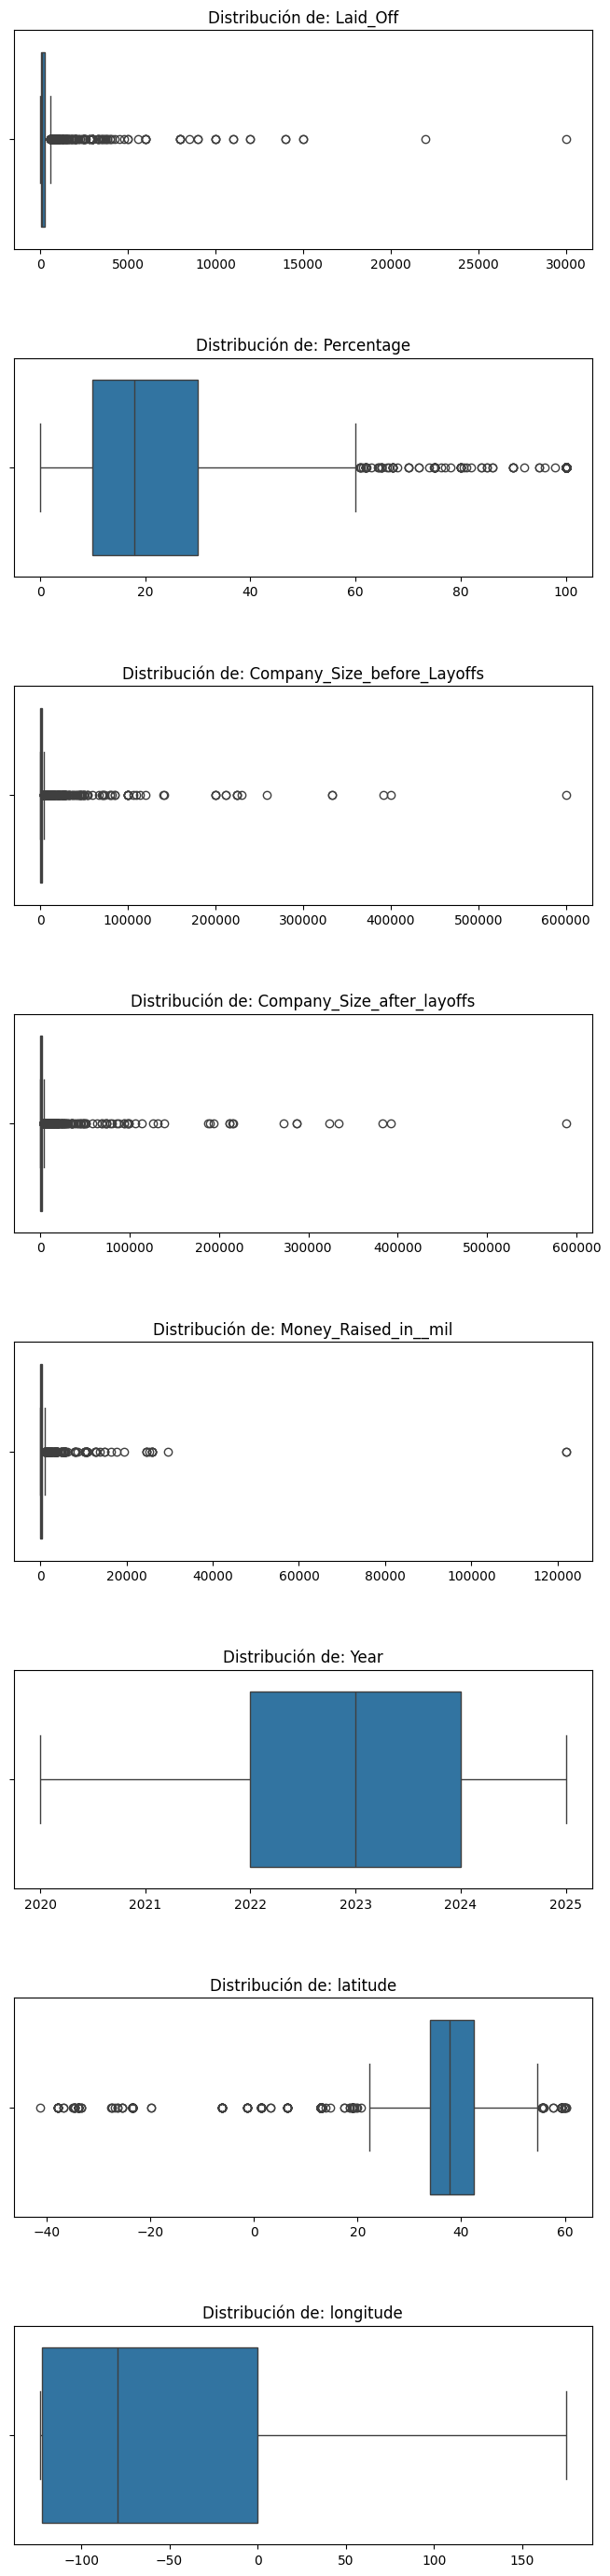
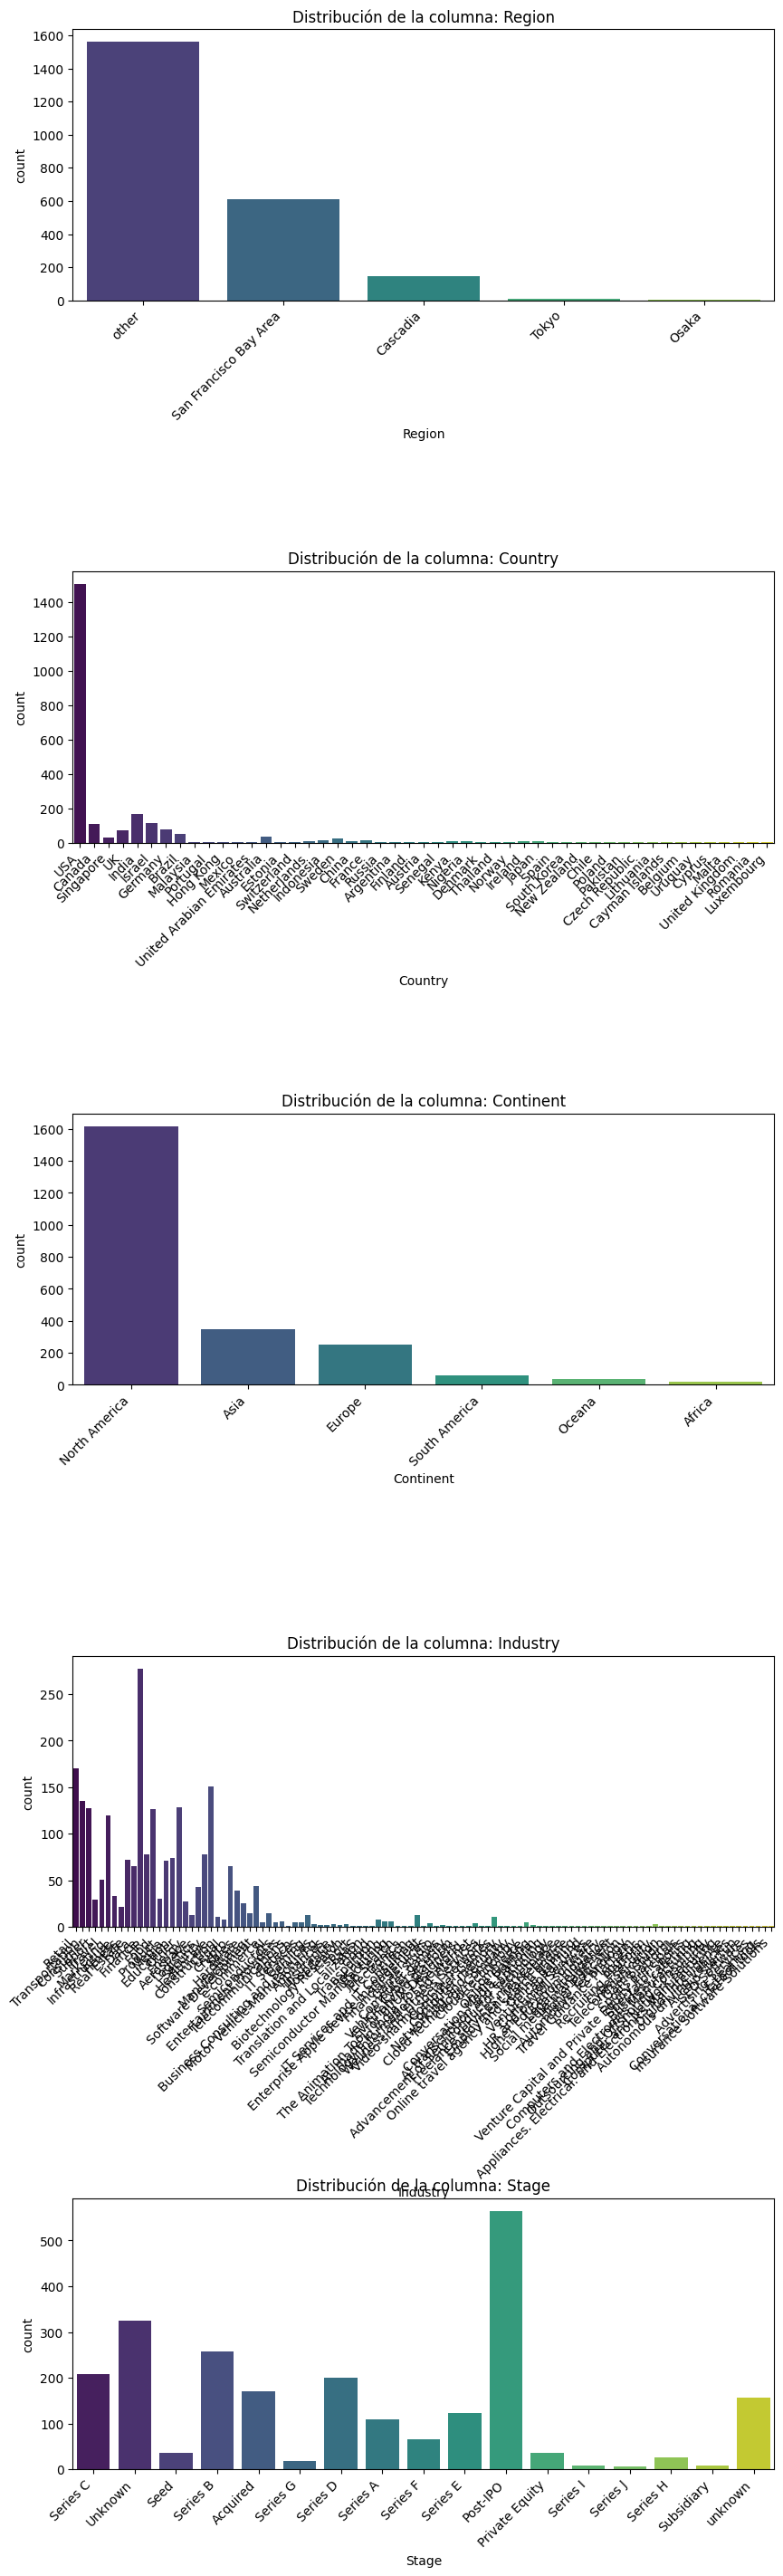
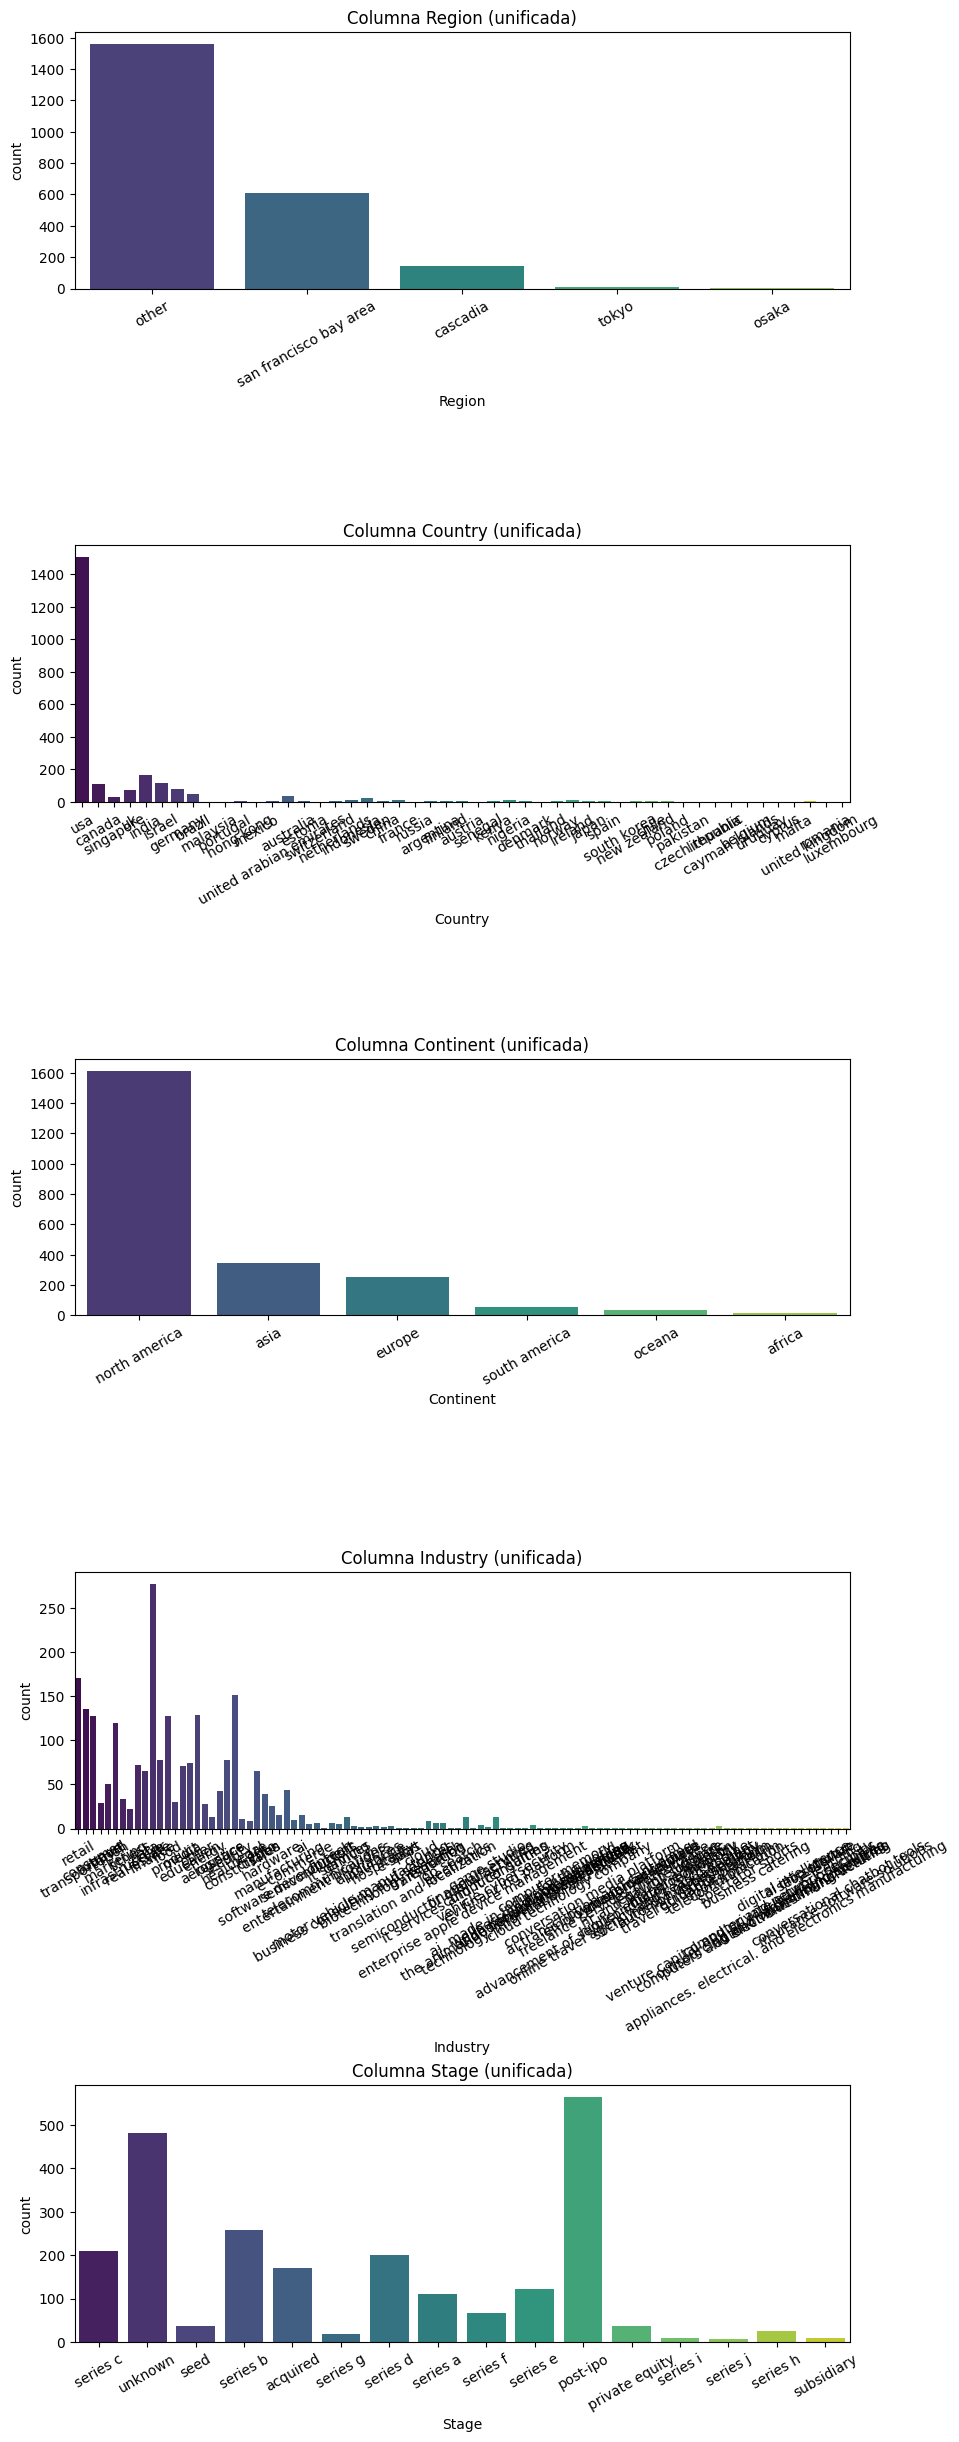
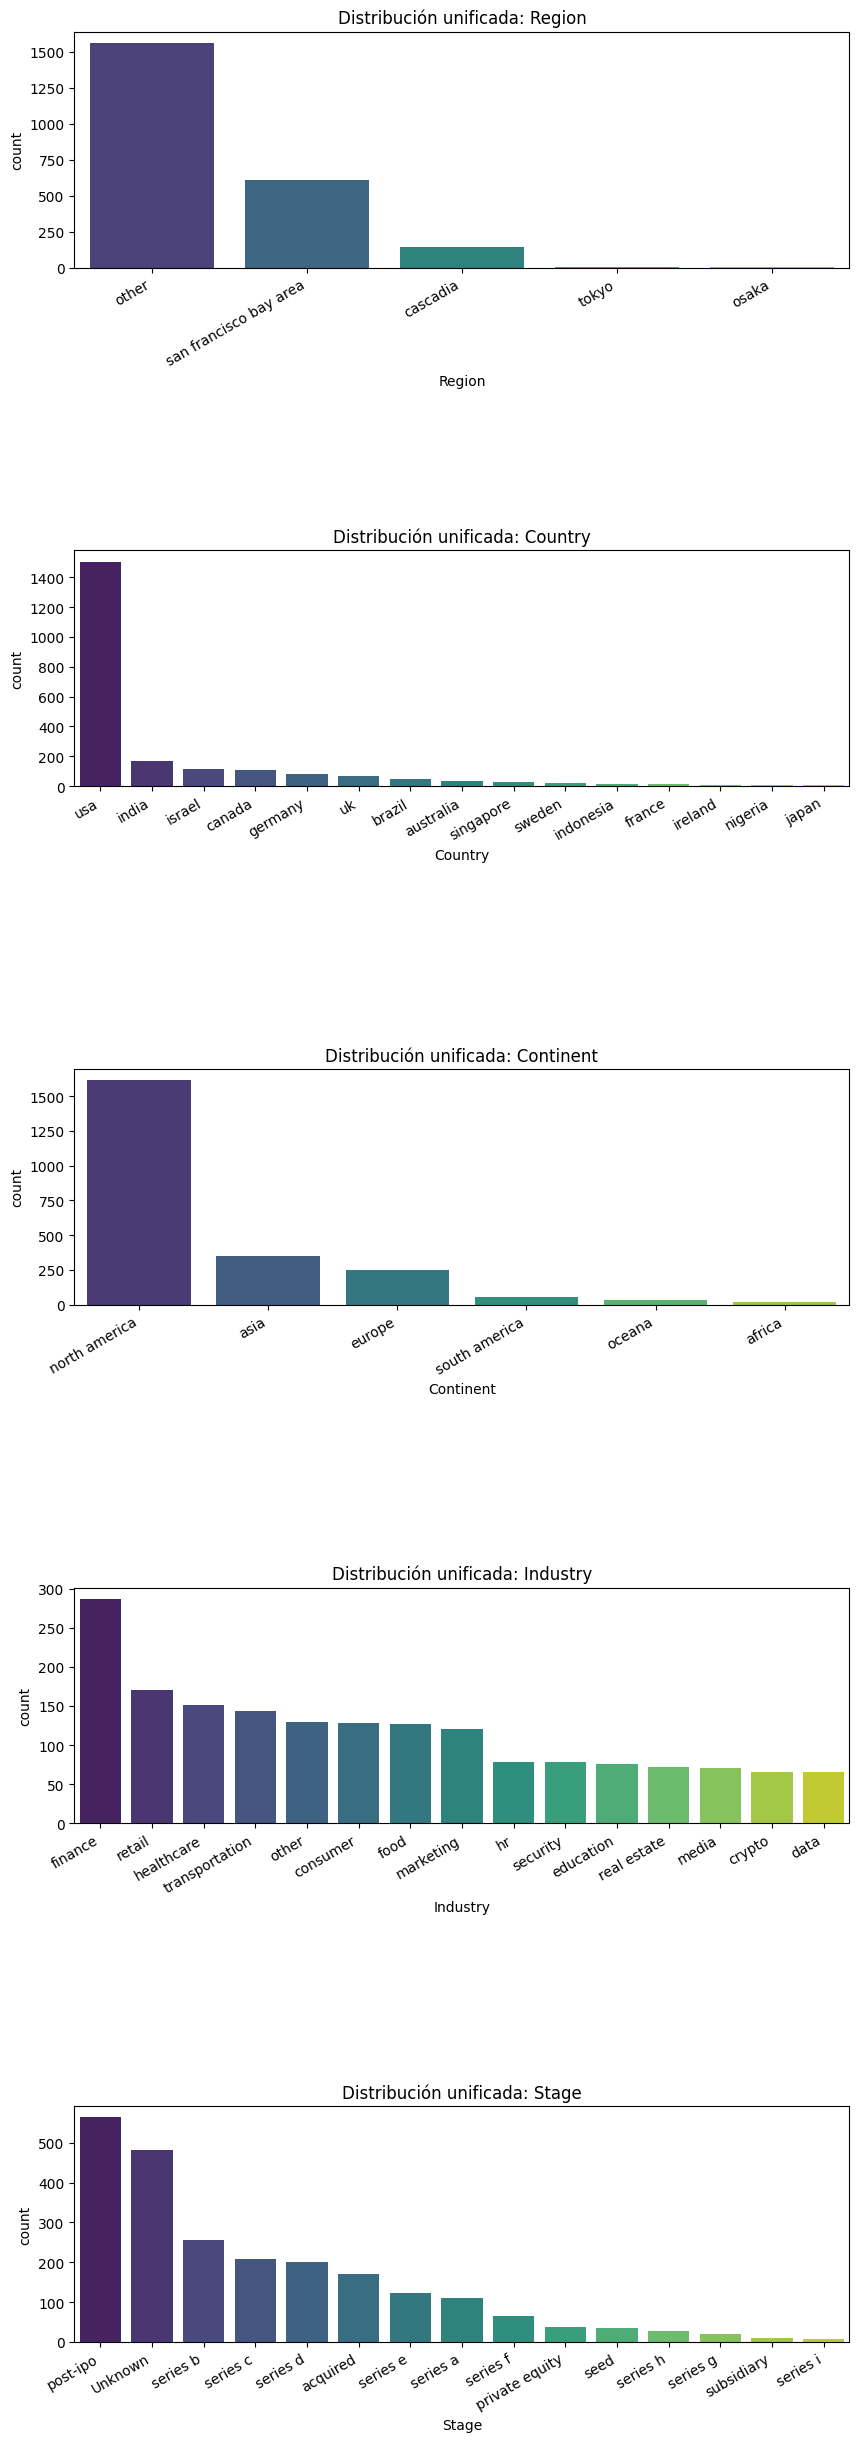

In [28]:
import requests
import os
from IPython.display import HTML

# 1. URL RAW del archivo en GitHub
url_raw = "https://raw.githubusercontent.com/natzasu13/BlanckProject/master/Limpieza_de_datos_Tech_Layoffs_2020_2025.ipynb"

try:
    # Descargar el notebook
    print("Descargando desde GitHub...")
    response = requests.get(url_raw)
    with open('limpieza.ipynb', 'wb') as f:
        f.write(response.content)

    # Convertirlo a HTML (Sin el comando --quiet)
    print("Convirtiendo a HTML...")
    !jupyter nbconvert --to html limpieza.ipynb

    # Verificar si el archivo se creó antes de intentar leerlo
    if os.path.exists('limpieza.html'):
        with open('limpieza.html', 'r', encoding='utf-8') as f:
            html_content = f.read()

        print("✅ ¡Todo listo! Notebook incrustado abajo:")
        # Mostramos el resultado dentro de un marco
        display(HTML(f'''
            <div style="height:600px; overflow:auto; border:3px solid #F9AB00; border-radius:10px; padding:10px;">
                {html_content}
            </div>
        '''))
    else:
        print("❌ Error: No se pudo generar el archivo HTML. Revisa los mensajes de arriba.")

except Exception as e:
    print(f"❌ Hubo un problema: {e}")



# 1. El problema del negocio

En los ultimos años algunas empresas multinacionales en el area de tecnologíaa, como Amazon, empezaron a despedir masivamente a sus empleados. Esto genera incertidumbre en los trabajadores de estas areas de negocio y nos lleva a cuestionarnos cuáles son los factores principales que conllevan a realizar estos despidos.

Para esta limpieza de datos se tomó el dataset de Kaggle **Tech Layoffs 2020 - 2025** que nos proporciona información de los despidos tecnológicos realizados entre los años 2020 y actualizado hasta el año 2025. En este dataset podemos encontrar varios países a nivel global, pero la mayoria de registros en Estados Unidos.

Nuestra pregunta a resolver con el análisis exploratorio es:

**¿Cuáles son los principales factores que influyen en los despidos de empleados en una empresa tecnológica?**

#2. El set de datos después de la limpieza

La dataset despues del proceso de limpieza con la información recolectada de los despidos de empresas en el area de tecnología se encuentra en el archivo CSV (`tech_layoffs_til_2025_clean.csv`) con 2321 filas y 17 columnas.

Cada registro contiene 17 características (las primeras 17 columnas) que describen el contexto de la empresa y la ubicación geográfica, y una columna de cierre que identifica el año del evento. Las columnas son:


1. "Company": nombre de la empresa que realizó los despidos (categórica)
2. "Location_HQ": ciudad de la sede principal de la empresa (categórica)
3. "Region": región geográfica de la sede (categórica)
4. "USState": estado de EE. UU., si aplica (categórica)
5. "Country": país de ubicación de la empresa (categórica)
6. "Continent": continente de ubicación de la empresa (categórica)
7. "Laid_Off": número de empleados despedidos (numérica)
8. "Date_layoffs": fecha del anuncio de los despidos (temporal)
9. "Percentage": porcentaje de despedidos (numérica: de 0 a 100)
10. "Company_Size_before_Layoffs": número de empleados antes del despido (numérica)
11. "Company_Size_after_layoffs": número de empleados después del despido (numérica)
12. "Industry": sector industrial de la empresa (categórica: "Retail", "Transportation", "Consumer", "Travel", etc.)
13. "Stage": etapa de financiación de la empresa (categórica: "Series C", "Seed", "Series B", "Post-IPO", "Acquired", etc.)
14. "Money_Raised_in__mil": dinero recaudado por la empresa en millones de dólares (numérica)
15. "Year": año en que se registraron los despidos (numérica)
16. "latitude": coordenada de latitud de la ubicación (numérica)
17. "longitude": coordenada de longitud de la ubicación (numérica)

#3. Lectura del dataset

In [29]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [30]:
# Lectura
from google.colab import drive
drive.mount('/gdrive')

ruta = "/gdrive/MyDrive/Colab Notebooks/retos_ciencias_de_datos/tech_layoffs_til_2025_clean.csv"
data = pd.read_csv(ruta)

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


In [31]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
print(data.shape)
data.head()

(2321, 17)


,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
0,Tamara Mellon,Los Angeles,other,California,usa,north america,20.0,2020-03-12,40.0,50.0,30.0,retail,series c,90.0,2020,34.053691,-118.242766
1,HopSkipDrive,Los Angeles,other,California,usa,north america,8.0,2020-03-13,10.0,80.0,72.0,transportation,Unknown,45.0,2020,34.053691,-118.242766
2,Panda Squad,San Francisco,san francisco bay area,California,usa,north america,6.0,2020-03-13,75.0,8.0,2.0,consumer,seed,1.0,2020,37.779259,-122.419329
3,Help.com,Austin,other,Texas,usa,north america,16.0,2020-03-16,100.0,16.0,0.0,support,seed,6.0,2020,30.271129,-97.743700
4,Inspirato,Denver,other,Colorado,usa,north america,130.0,2020-03-16,22.0,591.0,461.0,travel,series c,79.0,2020,39.739236,-104.984862


In [33]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=data)

https://docs.google.com/spreadsheets/d/1UheITwcmsp0qDWAqh7kMZnnCKaHuTz7ONzRL7mvqtf8/edit#gid=0


#4. Análisis exploratorio

La idea es usar herramientas estadísticas y de visualización para:

- Crear un mapa mental del set de datos (entenderlo)
- Empezar a encontrar respuestas a la pregunta planteada inicialmente (**¿Cuáles son los principales factores que influyen en los despidos de empleados en una empresa tecnológica?**)

Llevaremos a cabo estas fases:

1. Análisis de cada variable de manera individual
2. Análisis univariado: relación de cada variable predictora con la variable a predecir
3. Análisis bivariado: relación de pares de variables predictoras con la variable a predecir

##4.1 Análisis de cada variable de manera individual

Nos permite entender las características generales de cada variable de nuestro set de datos.

In [34]:
# Con data.info() podemos ver las variables categóricas
# (Dtype=object)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2321 entries, 0 to 2320
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Company                      2321 non-null   object 
 1   Location_HQ                  2321 non-null   object 
 2   Region                       2321 non-null   object 
 3   USState                      2321 non-null   object 
 4   Country                      2321 non-null   object 
 5   Continent                    2321 non-null   object 
 6   Laid_Off                     2321 non-null   float64
 7   Date_layoffs                 2321 non-null   object 
 8   Percentage                   2321 non-null   float64
 9   Company_Size_before_Layoffs  2321 non-null   float64
 10  Company_Size_after_layoffs   2321 non-null   float64
 11  Industry                     2321 non-null   object 
 12  Stage                        2321 non-null   object 
 13  Money_Raised_in__m

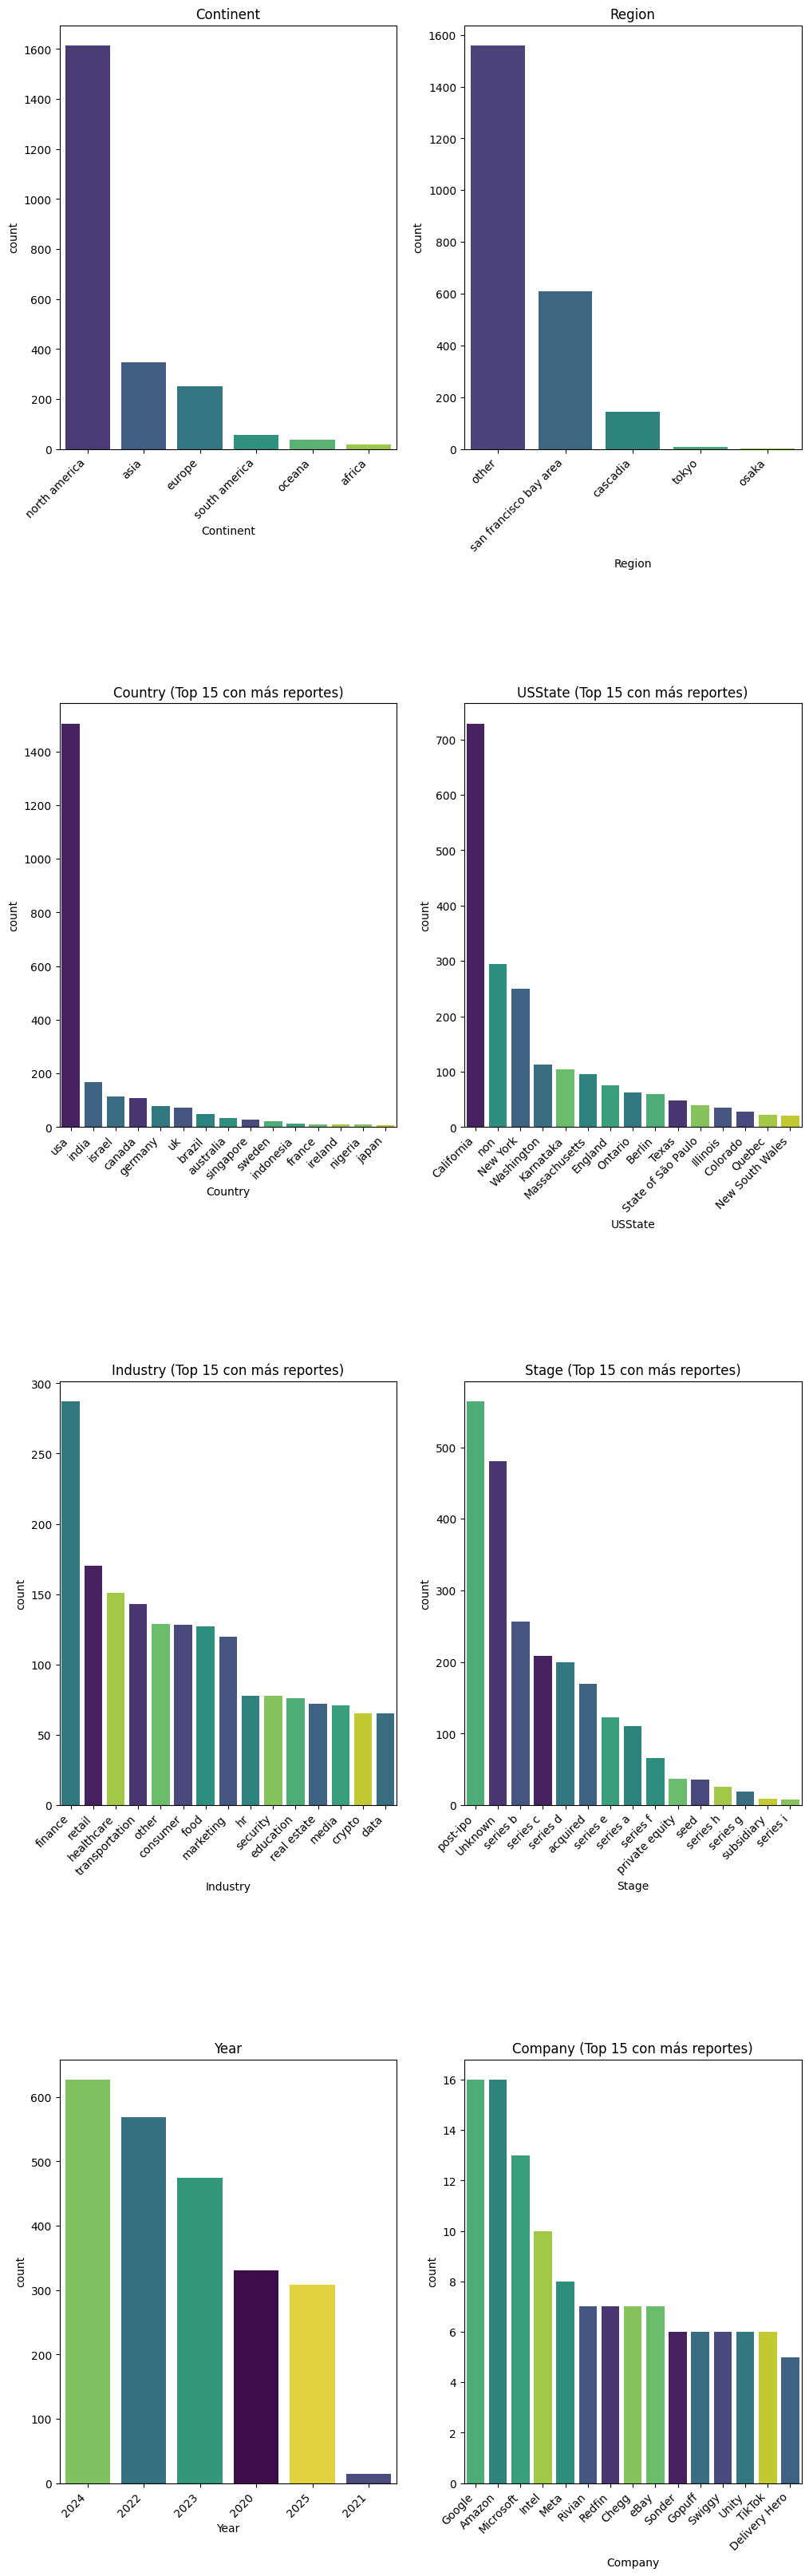

In [35]:
# Definimos las variables categóricas que queremos analizar y generemos gráficos de barras
col_cat = ['Continent', 'Region', 'Country', 'USState', 'Industry', 'Stage', 'Year', 'Company']

# Gráficos de barras de conteo
# Ajustamos el tamaño para 6 gráficos
fig, ax = plt.subplots(nrows=len(col_cat)//2, ncols=2, figsize=(12, 40))
fig.subplots_adjust(hspace=0.6) # Ajustamos el espacio vertical entre gráficos para que los títulos no se pisen

# Aplanamos la matriz de ejes (ax) para poder iterar sobre cada gráfico individualmente
axes = ax.flatten()

for i, col in enumerate(col_cat):
    current_ax = axes[i] # Use the flattened axis

    # Si la variable tiene muchos nombres únicos (como Company o Industry),
    # graficamos solo los 15 con mayor frecuencia para que sea legible
    if data[col].nunique() > 15:
        top_15 = data[col].value_counts().head(15).index
        sns.countplot(x=col, data=data[data[col].isin(top_15)], ax=current_ax, order=top_15, palette='viridis', hue=col, legend=False)
        current_ax.set_title(f'{col} (Top 15 con más reportes)')
    else:
        # Para variables con pocos niveles (como Continent o Year)
        sns.countplot(x=col, data=data, ax=current_ax, order=data[col].value_counts().index, palette='viridis', hue=col, legend=False)
        current_ax.set_title(col)

    # Rotamos las etiquetas para que no se traslapen
    current_ax.set_xticklabels(current_ax.get_xticklabels(), rotation=45, ha='right')

plt.show()

**Observaciones:**

Niveles de cada variable de interés:


- 'Continent': 6 (north america, asia, europe, south america, oceana, africa). La gran mayoría de los registros corresponden a 'north america'.
- 'Country': 49. La gran mayoría de los registros corresponden a 'usa'.
- 'Region': 5 (other, san francisco bay area, cascadia, tokyo, osaka). La gran mayoría de los registros corresponden a 'other'.
- 'USState': 76. El valor dominante es 'California', reflejando el peso del sector tecnológico en ese estado.
- 'Industry': 74. La distribución es variada; tras la limpieza, 'finance' es el nivel más frecuente.
- 'Stage': 16. Existe variedad de niveles, con 'post-ipo' como el más recurrente.
- 'Year': 6 (2020, 2021, 2022, 2023, 2024, 2025). El año con más despidos reportados es '2024'.

In [36]:
# Eliminemos las columnas "latitude" y "longitude"
# pues son identificadores o coordenadas que no aportan a los factores estadísticos que necesitamos para responder nuestra pregunta

data.drop(columns=['latitude', 'longitude'], inplace=True)
data.columns

Index(['Company', 'Location_HQ', 'Region', 'USState', 'Country', 'Continent',
       'Laid_Off', 'Date_layoffs', 'Percentage', 'Company_Size_before_Layoffs',
       'Company_Size_after_layoffs', 'Industry', 'Stage',
       'Money_Raised_in__mil', 'Year'],
      dtype='object')

Veamos inicialmente el comportamiento de las variables numéricas (`Laid_Off`, `Percentage`, `Company_Size_before_Layoffs` y `Money_Raised_in__mil`).

* Laid_Off: El número total de personas afectadas.
* Percentage: Qué tan grande fue el recorte en relación al tamaño de la empresa.
* Company_Size_before_Layoffs: El tamaño original de la organización.
* Money_Raised_in__mil: El respaldo financiero que tenía la empresa.

In [37]:
# Podemos extraer algunas variables estadísticas descriptivas básicas
data.describe()

,Laid_Off,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Money_Raised_in__mil,Year
count,2321.000000,2321.000000,2321.000000,2321.000000,2321.000000,2321.000000
mean,365.323053,24.177495,5232.178524,4764.198924,757.875965,2022.852219
std,1331.969611,22.589991,26436.799708,26311.978878,4153.990763,1.525969
min,1.000000,0.000000,4.000000,0.000000,0.000000,2020.000000
25%,47.000000,10.000000,267.000000,180.000000,64.000000,2022.000000
50%,100.000000,17.000000,700.000000,540.600000,204.000000,2023.000000
75%,250.000000,30.000000,2000.000000,1694.000000,507.000000,2024.000000
max,30000.000000,100.000000,600000.000000,588000.000000,121900.000000,2025.000000


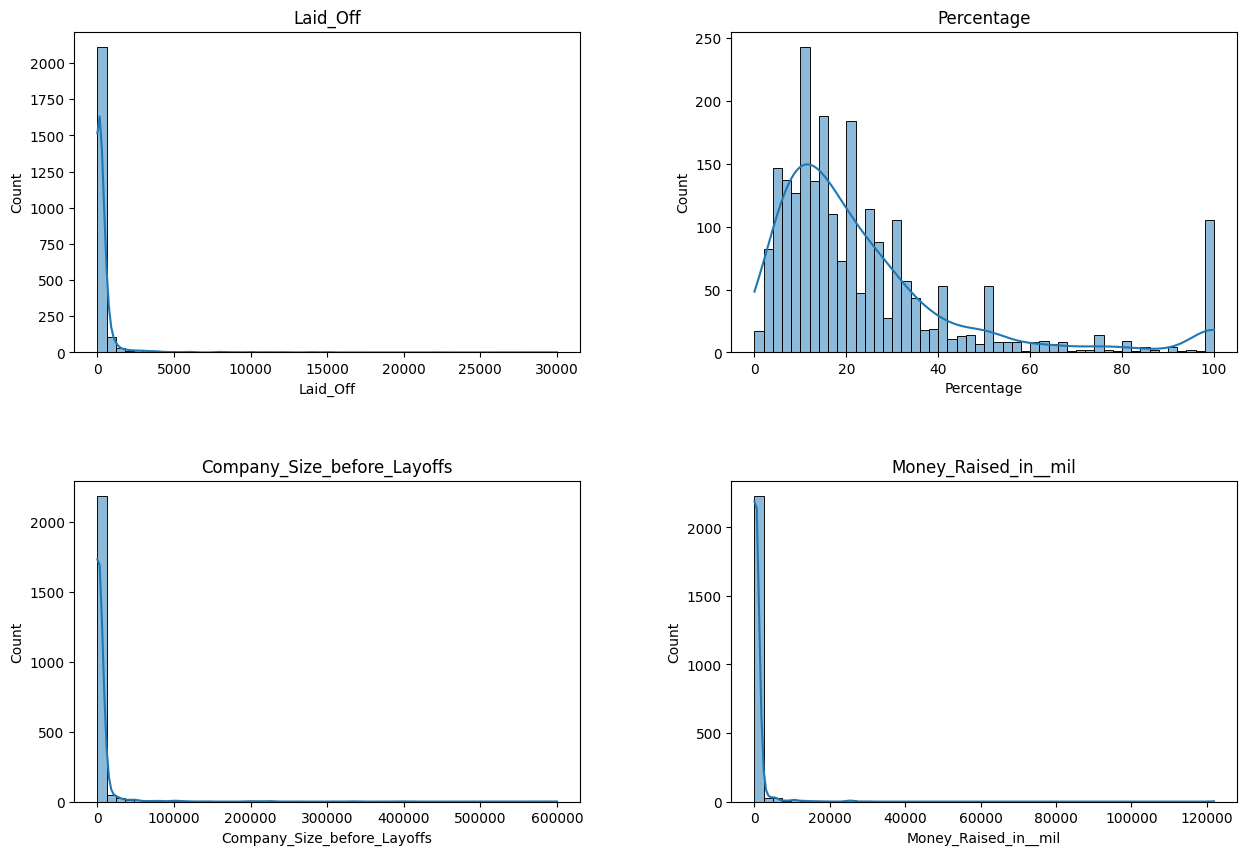

In [38]:
# Pero muchas veces es más útil graficar dichas variables

# Dibujar histogramas
col_num = ['Laid_Off', 'Percentage', 'Company_Size_before_Layoffs', 'Money_Raised_in__mil']

# Creamos la cuadrícula de 2x2 (necesitamos ajustar nrows y ncols)
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Aplanamos los ejes para que ax[i] funcione del 0 al 3
axes = ax.flatten()

for i, col in enumerate(col_num):
    # Ajustamos los bins: 50 un buen número para ver la distribución
    sns.histplot(x=col, data=data, ax=axes[i], bins=50, kde=True)
    axes[i].set_title(col)

In [39]:
# Laid_Off (número de empleados despedidos (numérica))
# codigo: data['Laid_Off'].describe()
# Percentage (porcentaje de despedidos (numérica: de 0 a 100))
# Money_Raised_in__mil ( dinero recaudado por la empresa en millones de dólares (numérica))

# Seleccionamos las columnas numéricas
columnas_num = ['Laid_Off', 'Percentage', 'Money_Raised_in__mil']

# Generamos el resumen estadístico descriptivo
resumen = data[columnas_num].describe().round(2)

# Función para aplicar estilos (Subrayar lo importante)
def destacar_hallazgos(x):
    df_styler = pd.DataFrame('', index=x.index, columns=x.columns)
    # Mediana (50%) - Verde
    df_styler.loc['50%', :] = 'background-color: #d1e7dd; text-decoration: underline; font-weight: bold'
    # Mayoría (75%) - Amarillo
    df_styler.loc['75%', :] = 'background-color: #fff3cd; text-decoration: underline; font-weight: bold'
    # Promedio Inflado - Rojo
    df_styler.loc['mean', 'Laid_Off'] = 'background-color: #f8d7da; text-decoration: underline; font-weight: bold'
    return df_styler

# Mostramos la tabla
resumen.style.apply(destacar_hallazgos, axis=None).format(precision=2)

,Laid_Off,Percentage,Money_Raised_in__mil
count,2321.00,2321.00,2321.00
mean,365.32,24.18,757.88
std,1331.97,22.59,4153.99
min,1.00,0.00,0.00
25%,47.00,10.00,64.00
50%,100.00,17.00,204.00
75%,250.00,30.00,507.00
max,30000.00,100.00,121900.00


**Variables analizadas**
- **Laid_Off** :número de empleados despedidos
- **Percentage** : porcentaje de despedidos
- **Money_Raised_in__mil** : dinero recaudado por la empresa en millones de dólares

**Observaciones:**

- `Laid_Off` La mayor parte del grupo de empresas afectadas ($75\%$) realizó despidos de $250$ personas o menos, con un sesgo hacia los $100$ empleados (mediana).
- `Percentage` La mayor parte del grupo de organizaciones ($75\%$) aplicó recortes del $30\%$ o menos, con una tendencia central del $17\%$ (mediana).
- `Money_Raised_in__mil` La mayor parte del grupo de compañías ($75\%$) contaba con un capital recaudado que no supera los $\$507$ millones, situándose la mitad por debajo de los $\$204$ millones (mediana).
- `Laid_Off` El promedio de despidos ($365$) está inflado por casos atípicos extremos, mientras que la realidad predominante es de escala mediana.

##4.2 Análisis univariado

Teniendo claras algunas características generales de cada dato individual, la idea ahora es analizar si existe alguna relación entre las posibles variables predictoras (`Industry`, `Stage`, `Continent`, `Money_Raised_in__mil`, etc.) y la variable a predecir (`Laid_Off`).

Esto se conoce como análisis univariado.

⚠️⚠️⚠️ ADVERTENCIA ⚠️⚠️⚠️

Este análisis nos mostrará sólo una faceta de las posibles relaciones entre una cada variable predictora y la variable a predecir, y no es suficiente para extraer conclusiones definitivas.

In [41]:
# Comencemos representando la variable a predecir de forma binaria:
# Definimos: 1 = Alto Impacto (>100 despidos), 0 = Bajo Impacto (<=100 despidos)

# Esto reemplaza al diccionario de 'yes'/'no'
# diccionario = {'yes':1, 'no':0}
# binario = data['Laid_Off'].map(diccionario)
# data['y_bin'] = binario

# Reemplazamos la lógica del diccionario por una condición lógica
data['y_bin'] = (data['Laid_Off'] > 100).astype(int)

# Calculamos la "Tasa de despidos de alto impacto": el promedio de 'y_bin'
tasa_alto_impacto = data['y_bin'].mean()

print(f"La tasa de despidos de alto impacto es: {tasa_alto_impacto:.4f}")

La tasa de despidos de alto impacto es: 0.4757


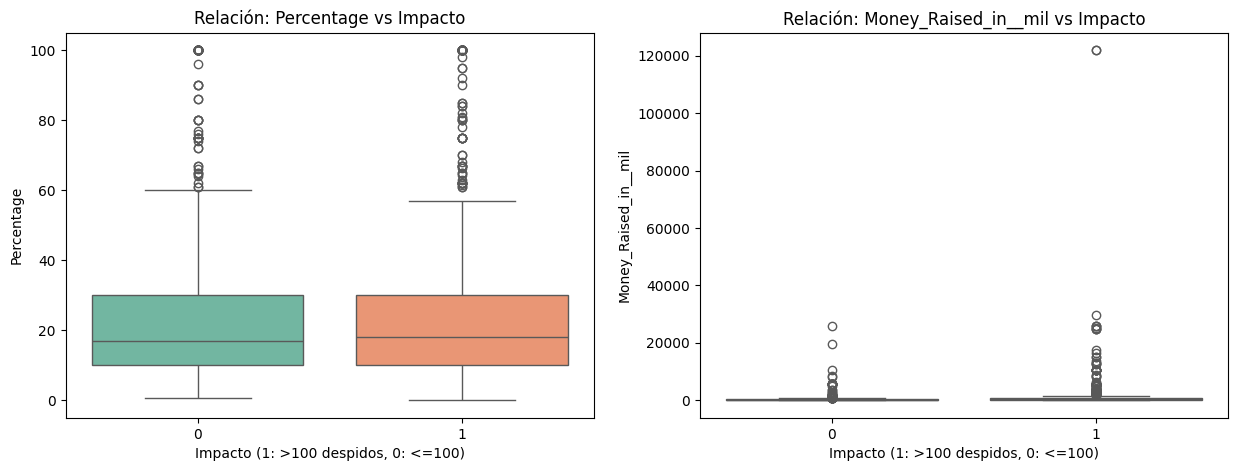

In [42]:
# Analizar la relación entre las variables numéricas y la variable a predecir ('y')
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos las variables numéricas predictoras
col_num = ['Percentage', 'Money_Raised_in__mil']

# Analizar la relación entre las variables numéricas y la variable a predecir ('y_bin')
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
fig.subplots_adjust(hspace=.25)

for i, col in enumerate(col_num):
    # Graficamos el impacto (0 o 1) contra cada variable numérica
    sns.boxplot(x="y_bin", y=col, data=data, ax=ax[i], palette='Set2')

    # Ajustamos etiquetas para que coincidan con tu análisis
    ax[i].set_xlabel('Impacto (1: >100 despidos, 0: <=100)')
    ax[i].set_title(f'Relación: {col} vs Impacto')

plt.show()

**Observaciones:**
- Ni en `Percentage` ni en `Money_Raised_in__mil` se observan diferencias drásticas en la tendencia central (mediana) entre las empresas que tuvieron despidos de alto impacto o bajo impacto.
- Al parecer, las variables numéricas no resultan en principio siendo variables predictivas por sí solas.

Sin embargo estas variables numéricas se encuentran en un amplio rango de valores (gran dispersión y presencia de valores atípicos).

Podemos calcular las tasas de conversión definiendo intervalos para estas variables numéricas y ver si podemos extraer información relevante de ese análisis:

In [46]:
# Función para graficar tasas de conversión

def graficar_tasas_conversion(var_predictora, var_predecir='y_bin', type='line', order=None):
    x, y = var_predictora, var_predecir

    # Generar agrupaciones (groupby), calcular tasa de "conversión" (mean),
    # multiplicarla por 100 (mul(100)) para obtener el porcentaje
    grupo = data.groupby(x)[y].mean().mul(100).rename('tasa_conv').reset_index()

    # Y generar gráfica
    if type=='line': # Útil para rangos numéricos o temporales
        plt.figure(figsize=(10,6))
        sns.lineplot(x=var_predictora, y='tasa_conv', data=grupo, marker='o')
        plt.ylabel('Tasa de Despidos Masivos (%)')
        plt.grid(True)

    elif type=='bar': # Útil para categorías (Industria, Continente)
        plt.figure(figsize=(14,6))
        sns.barplot(x=var_predictora, y='tasa_conv', data=grupo, order=order, palette='viridis')
        plt.ylabel('Tasa de Despidos Masivos (%)')
        plt.xticks(rotation=45)
        plt.grid(axis='y')

    elif type=='scatter': # Útil para visualizar dispersión de tasas
        plt.figure(figsize=(10,6))
        sns.scatterplot(x=var_predictora, y='tasa_conv', data=grupo, s=100)
        plt.ylabel('Tasa de Despidos Masivos (%)')
        plt.grid(True)

    plt.title(f'Análisis de Relación: {var_predictora} vs Tasa de Despidos')
    plt.show()

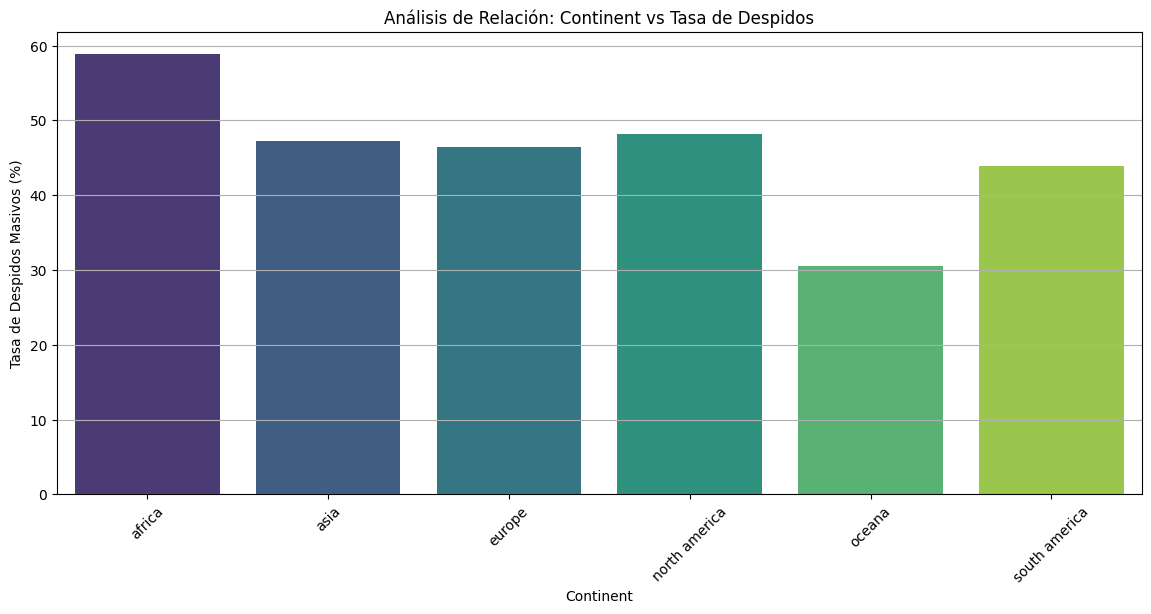

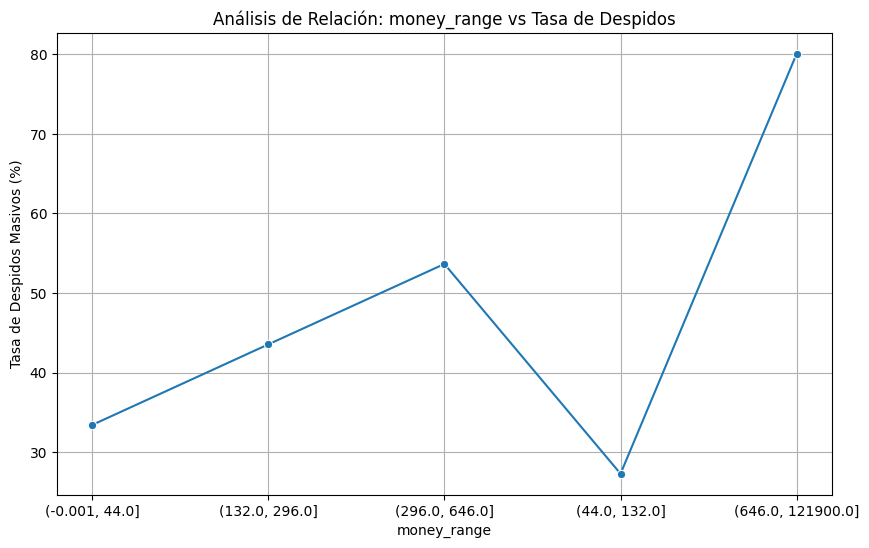

In [47]:
# Y graficar las tasas de conversión para la variable Continente
graficar_tasas_conversion('Continent', 'y_bin', type='bar')

# Creamos los intervalos para el Dinero Recaudado (5 grupos)
# Usamos .astype(str) para que la gráfica no dé error al leer los rangos
data['money_range'] = pd.qcut(data['Money_Raised_in__mil'], q=5).astype(str)

# Graficamos la tasa para ver la tendencia
graficar_tasas_conversion('money_range', 'y_bin', type='line')

**Observaciones:**

- En este caso SÍ se observan diferencias en las tasas de conversión por edad
- Podríamos establecer tres rangos aproximados: 18-25 años, 26-59 años y 60 años en adelante



**Observaciones (Caso: Dinero Recaudado)**
- En este caso SÍ se observan diferencias en las tasas de despidos masivos (conversión) según el capital recaudado (`Money_Raised_in__mil`).
- Podríamos establecer tres rangos aproximados de impacto basados en el financiamiento: `Bajo capital` (menor probabilidad de despidos masivos), `Capital Intermedio` (probabilidad creciente) y `Alto capital` (máxima probabilidad de despidos masivos).
- Esto confirma que el capital recaudado es una variable con alto poder predictivo para determinar la magnitud del recorte de personal.

**Observaciones (Caso: Continente)**
- En este caso SÍ se observan diferencias en las tasas de despidos masivos según la ubicación geográfica (`Continent`).
-  Podríamos establecer tres grupos según su comportamiento: `North America `(con la tasa de impacto más alta), seguido por `Europe` y `Asia`, y finalmente regiones con menor tasa de eventos masivos como `South America` o `Africa`.
- Al parecer, la madurez del mercado tecnológico y el tamaño de las empresas en cada región influyen directamente en la tasa de conversión a despidos de gran escala.

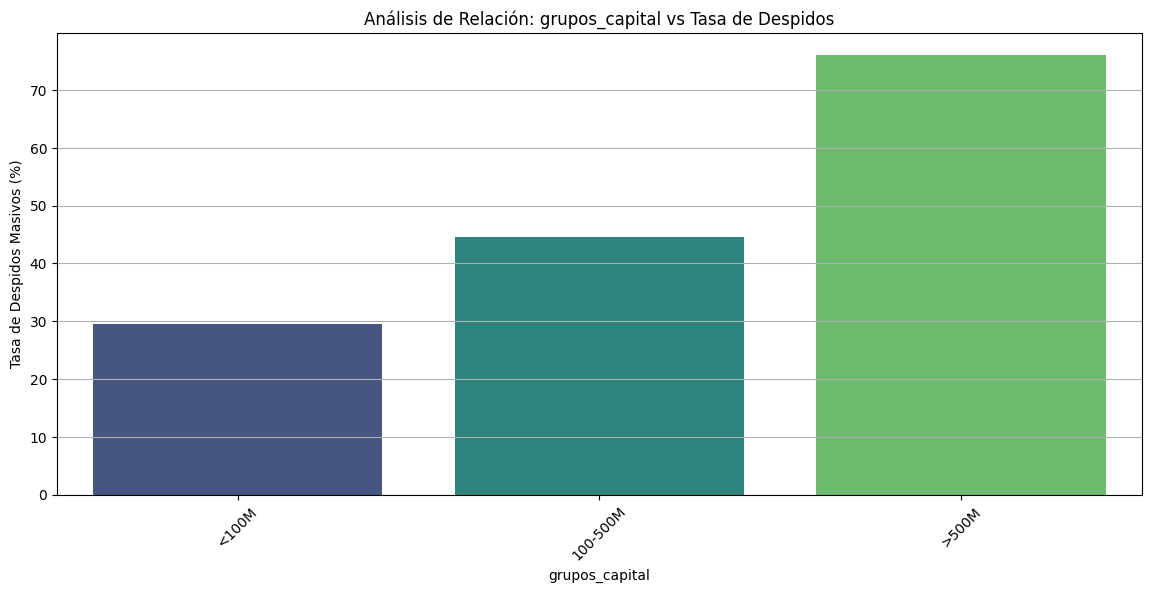

In [48]:
# Creemos subgrupos de capital recaudado y calculemos las tasas en cada caso

# Nueva columna en el dataset: "grupos_capital"
# Definimos los rangos: <100M (Bajo), 100-500M (Medio), >500M (Alto)

data.loc[:, 'grupos_capital'] = "100-500M" # Valor por defecto (Medio)
data.loc[data['Money_Raised_in__mil'] < 100, 'grupos_capital'] = "<100M"
data.loc[data['Money_Raised_in__mil'] > 500, 'grupos_capital'] = ">500M"

# Y grafiquemos la tasa de conversión para esta nueva columna
# Usamos 'bar' porque ahora son categorías de texto
graficar_tasas_conversion('grupos_capital', 'y_bin', type='bar', order=['<100M', '100-500M', '>500M'])

**Observaciones:**

- Tenemos 3 rangos de capital bastante diferenciados y para los cuales se alcanzan diferentes tasas de despidos masivos: <100M ($29\%$), 100-500M ($45\%$), más de 500M ($76\%$).


In [49]:
# Y eliminemos la columna "Money_Raised_in__mil" (dejando sólo los grupos de capital)
data.drop(columns=['Money_Raised_in__mil'], inplace=True)

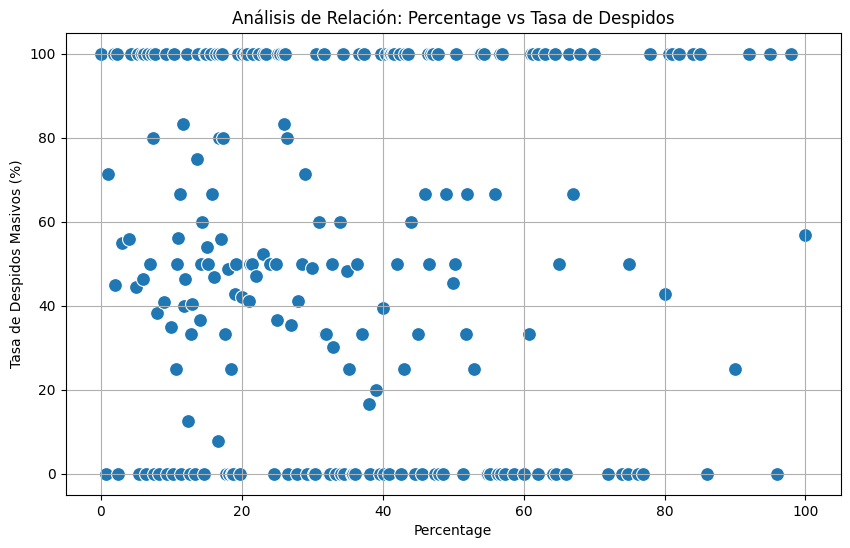

In [50]:
# Realicemos el mismo análisis pero para la variable 'Percentage'
graficar_tasas_conversion('Percentage','y_bin',type='scatter')

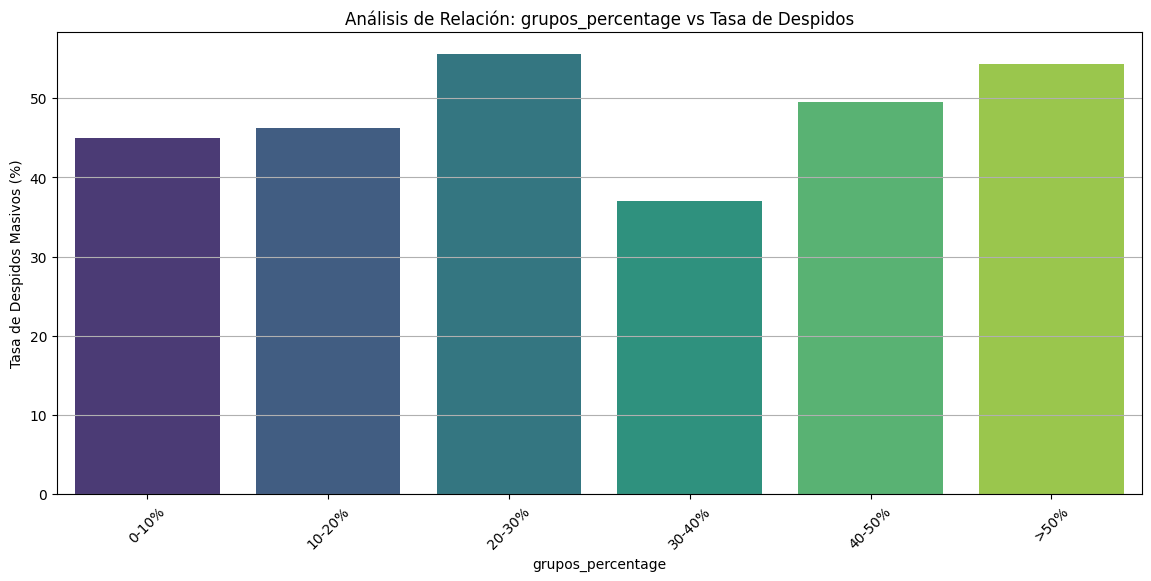

In [51]:
# No resulta fácil ver un patrón. Al igual que con Money_Raised_in__mil generemos
# 0-10%
# 10-20%
# 20-30%
# 30-40%
# 40-50%
# >50%

# Nueva columna en el dataset: "grupos_percentage"
data.loc[:,'grupos_percentage'] = "0-10%"
data.loc[(data['Percentage']>10) & (data['Percentage']<=20), 'grupos_percentage'] = "10-20%"
data.loc[(data['Percentage']>20) & (data['Percentage']<=30), 'grupos_percentage'] = "20-30%"
data.loc[(data['Percentage']>30) & (data['Percentage']<=40), 'grupos_percentage'] = "30-40%"
data.loc[(data['Percentage']>40) & (data['Percentage']<=50), 'grupos_percentage'] = "40-50%"
data.loc[data['Percentage']>50, 'grupos_percentage'] = ">50%"

# Y grafiquemos la tasa de conversión para esta nueva columna
orden_pct = ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%", ">50%"]
graficar_tasas_conversion('grupos_percentage', 'y_bin', type='bar', order=orden_pct)

**Observaciones:**

- Al parecer hay un patrón. Si organizamos las barras de forma ascendente observamos los siguientes porcentajes de despidos masivos por cada rango:
  - 0-10%: 24%
  - 10-20%: 48%
  - 20-30%: 50%
  - 30-40%: 51%
  - 40-50%: 45%
  - Mayor al 50%: 22%

- Exceptuando el rango de Mayor al 50%, en general un mayor porcentaje de recorte genera una mayor probabilidad de que el evento sea un despido masivo (superior a 100 personas). La caída en el último rango se explica porque los despidos del 100% suelen ocurrir en **startups** muy pequeñas que no alcanzan el umbral de los 100 empleados.

- Podríamos definir 3 rangos de interés para simplificar el análisis:
  - 0-10% (Bajo impacto)
  - 10-50% (Zona crítica de despidos masivos)
  - Mayor al 50% (Cierres de empresas pequeñas)

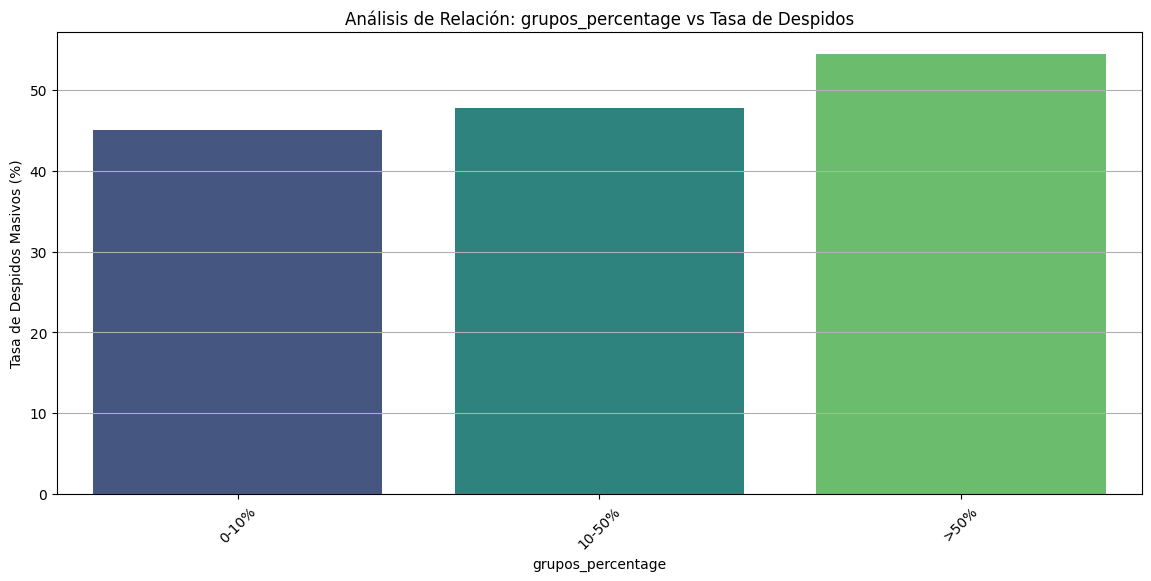

In [52]:
# Generemos el dataset únicamente con estos rangos y observemos el comportamiento
# Simplificamos los grupos de porcentaje basado en que entre 10% y 50% las tasas eran similares

# Nueva columna en el dataset: "grupos_percentage"
data.loc[:,'grupos_percentage'] = "0-10%"
data.loc[(data['Percentage']>10) & (data['Percentage']<=50), 'grupos_percentage'] = "10-50%"
data.loc[data['Percentage']>50, 'grupos_percentage'] = ">50%"

# Y grafiquemos la tasa de conversión para esta nueva columna
orden = ['0-10%', '10-50%', '>50%']
graficar_tasas_conversion('grupos_percentage', 'y_bin', type='bar', order=orden)

In [53]:
# Y eliminemos la columna "Percentage" (dejando sólo los grupos_percentage)
data.drop(columns=['Percentage'], inplace=True)

Ahora realizaremos un análisis similar pero para las variables categóricas:

<Figure size 2200x1000 with 0 Axes>

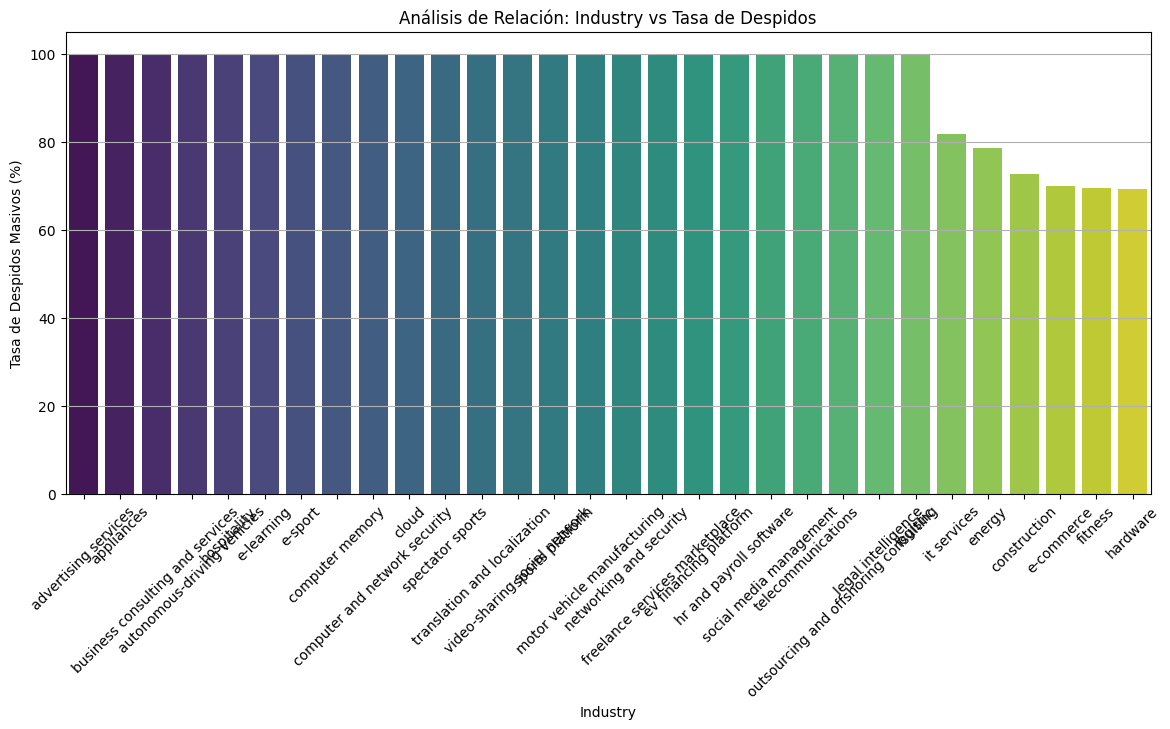

Tasa de Conversión para las observaciones
Industry
advertising services                     100.0
appliances                               100.0
business consulting and services         100.0
autonomous-driving vehicles              100.0
hospitality                              100.0
e-learning                               100.0
e-sport                                  100.0
computer memory                          100.0
computer and network security            100.0
cloud                                    100.0
spectator sports                         100.0
translation and localization             100.0
video-sharing social network             100.0
sports platform                          100.0
motor vehicle manufacturing              100.0
networking and security                  100.0
freelance services marketplace           100.0
ev financing platform                    100.0
hr and payroll software                  100.0
social media management                  100.0
telecommu

In [54]:
# Graficamos la tasa de conversión (despidos > 100) para todas las Industria
# graficar_tasas_conversion('Industry', 'y_bin', type='bar')

# Calculamos la tasa de impacto y el conteo por industria para todas las categorías
resumen_industria = data.groupby('Industry')['y_bin'].agg(['mean', 'count'])

# Obtenemos el orden de las industrias de mayor a menor tasa para el Top 30, para hacer la gráfica más legible
top_30_industrias = resumen_industria['mean'].sort_values(ascending=False).head(30).index

# Generamos el análisis visual usando la función para las industrias con mayor impacto
# Ajustamos el tamaño de la imagen
plt.figure(figsize=(22,10))
graficar_tasas_conversion('Industry', 'y_bin', type='bar', order=top_30_industrias)

# Imprimimos los valores exactos para redactar las observaciones del análisis
print("Tasa de Conversión para las observaciones")
print((resumen_industria['mean'].sort_values(ascending=False).head(30) * 100).round(1))

**Observaciones:**

- Se observa un grupo significativo de industrias con una tasa de conversión del **100%**, lo que indica que en sectores como `advertising services`, `hospitality` y `telecommunications`, lo que indica que en estos sectores la totalidad de los eventos registrados fueron despidos de alto impacto.
- Las tasas de despidos masivos oscilan entre el 10% y el 100% aproximadamente según el sector industrial analizado.
- Se destacan sectores como **IT Services** y **Energy** con tasas de conversión muy elevadas (**81.8% y 78.6%** respectivamente).
- Sectores de alto volumen transaccional como **E-commerce** y **Fitness** también mantienen niveles críticos de despidos masivos, **superando el 69%.**
- `Industry` **se confirma como una variable predictora fundamental debido a la alta variabilidad en la probabilidad de eventos masivos entre sectores.**

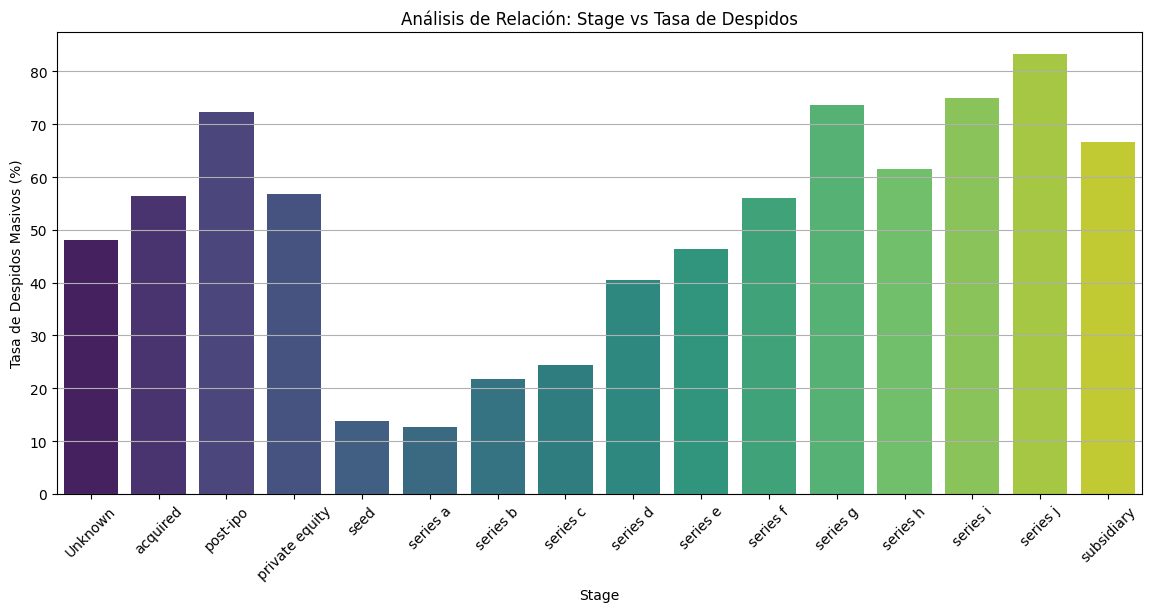

Stage
series j          83.333333
series i          75.000000
series g          73.684211
post-ipo          72.340426
subsidiary        66.666667
series h          61.538462
private equity    56.756757
acquired          56.470588
series f          56.060606
Unknown           48.024948
series e          46.341463
series d          40.500000
series c          24.401914
series b          21.789883
seed              13.888889
series a          12.727273
Name: y_bin, dtype: float64


In [55]:
# Análisis por Etapa
graficar_tasas_conversion('Stage', 'y_bin', type='bar')

# El promedio de una variable de 0 y 1 es exactamente la tasa de conversión
resumen_stage = data.groupby('Stage')['y_bin'].mean().sort_values(ascending=False)

# Multiplicamos por 100 para sacar el porcentaje
print(resumen_stage * 100)

**Observaciones:**

- Las tasas de conversión son muy diferentes para los diferentes niveles en la variable `Stage`.
- `Stage` parece ser una variable **predictora** clave, ya que se observa que a medida que la empresa es más madura, la probabilidad de que el despido sea masivo aumenta drásticamente.

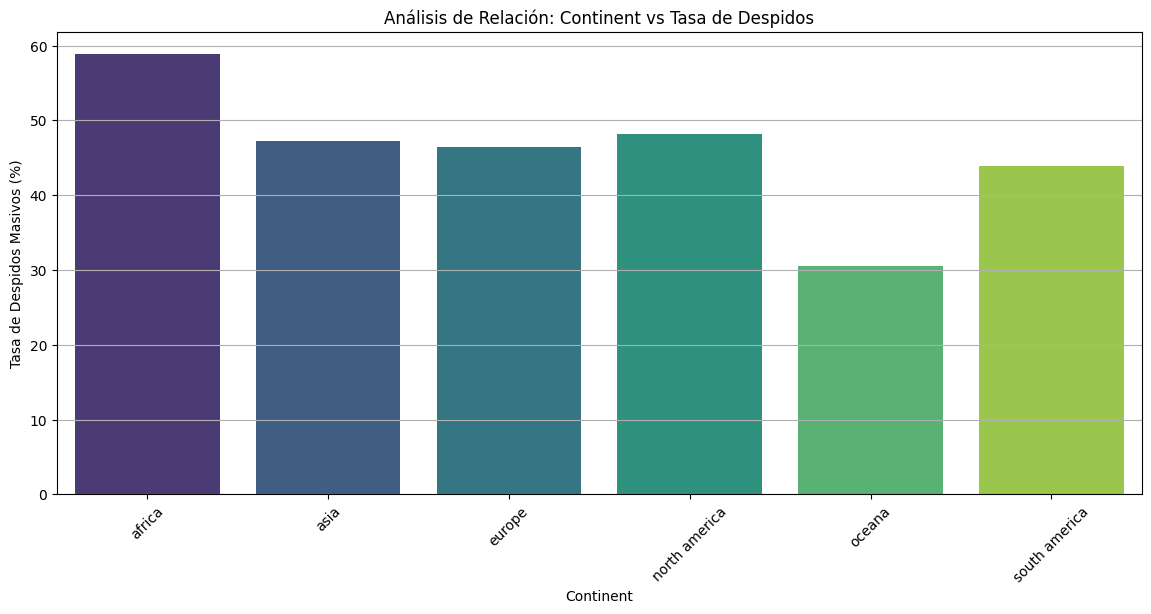

Tasa de Conversión por Continente:
Continent
africa           58.8
north america    48.2
asia             47.3
europe           46.4
south america    43.9
oceana           30.6
Name: y_bin, dtype: float64


In [56]:
# Análisis por Continente
graficar_tasas_conversion('Continent', 'y_bin', type='bar')

# Agrupamos por continente y calculamos el promedio de la variable binaria
resumen_continente = data.groupby('Continent')['y_bin'].mean().sort_values(ascending=False)

# Mostramos los resultados en porcentaje
print("Tasa de Conversión por Continente:")
print((resumen_continente * 100).round(1))


**Observaciones:**

- Las tasas de conversión son muy similares para la variable `Continent`(Norteamérica, Asia y Europa presentan una diferencia menor al 2%).

- `Continent` parece no ser una variable predictora fuerte, ya que el hecho de que una empresa esté en uno u otro continente no cambia significativamente la probabilidad de que ocurra un despido masivo.

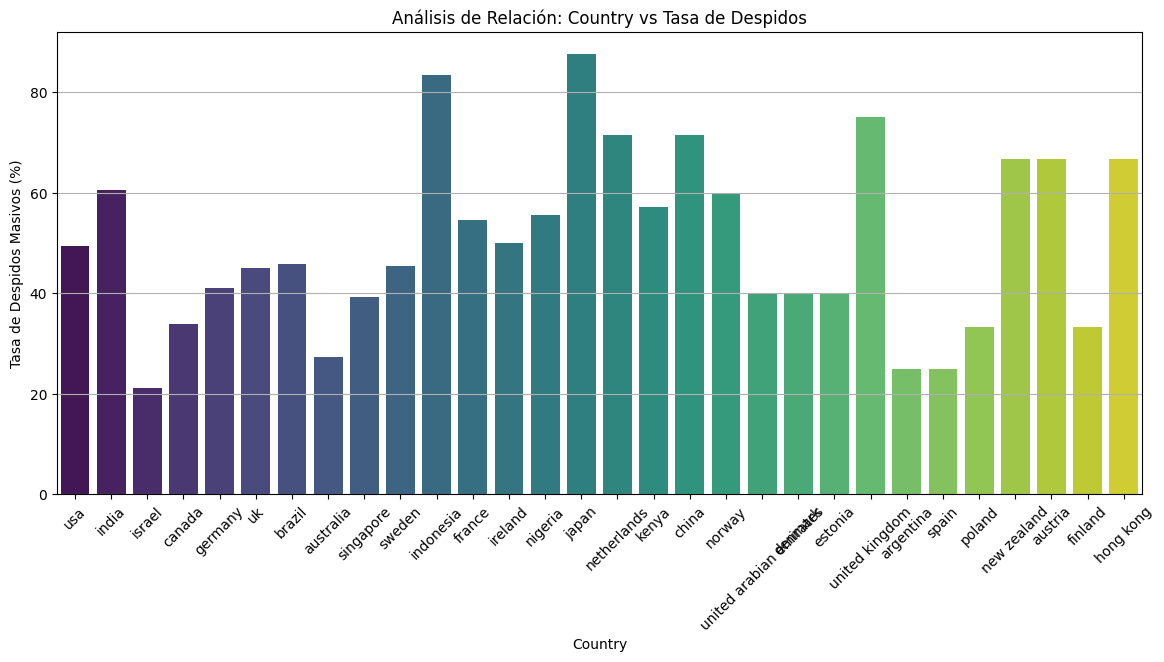

Tasa de Conversión por País (Top 30):
Country
japan                      87.5
indonesia                  83.3
united kingdom             75.0
netherlands                71.4
china                      71.4
hong kong                  66.7
new zealand                66.7
austria                    66.7
india                      60.5
norway                     60.0
kenya                      57.1
nigeria                    55.6
france                     54.5
ireland                    50.0
usa                        49.4
brazil                     45.8
sweden                     45.5
uk                         45.1
germany                    41.0
estonia                    40.0
denmark                    40.0
united arabian emirates    40.0
singapore                  39.3
canada                     33.9
finland                    33.3
poland                     33.3
australia                  27.3
argentina                  25.0
spain                      25.0
israel                    

In [57]:
# Análisis por País (Top 30 para mayor claridad)
top_paises = data['Country'].value_counts().head(30).index
graficar_tasas_conversion('Country', 'y_bin', type='bar', order=top_paises)

#Calculamos la tasa de conversión
resumen_pais = data[data['Country'].isin(top_paises)].groupby('Country')['y_bin'].mean().sort_values(ascending=False)

# Imprimimos el porcentaje
print("Tasa de Conversión por País (Top 30):")
print((resumen_pais * 100).round(1))


**Observaciones**:

- Las tasas de conversión son muy diferentes para los diferentes niveles en la variable `Country` (existe una gran dispersión, con picos por encima del 80% y valles por debajo del 25%).

- `Country` parece ser una variable predictora, ya que el comportamiento de los despidos masivos varía significativamente dependiendo del país donde se encuentra la empresa.

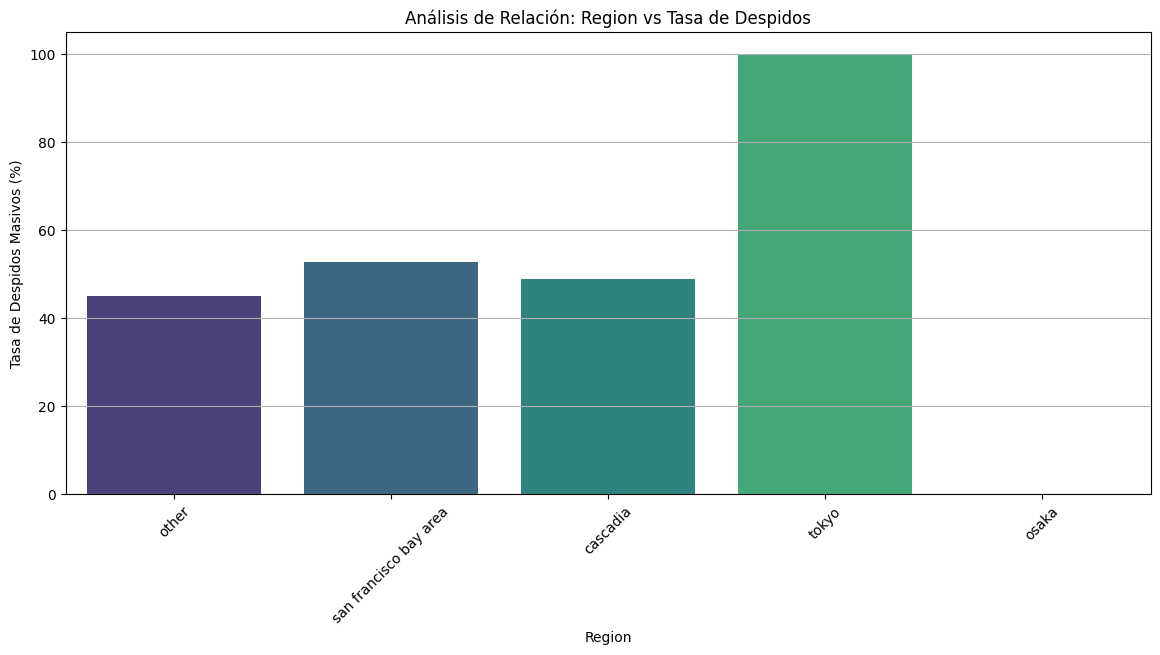

Tasa de Conversión por Región (Top 30):
Region
tokyo                     100.0
san francisco bay area     52.9
cascadia                   49.0
other                      45.2
osaka                       0.0
Name: y_bin, dtype: float64


In [58]:
# Identificamos las regiones con más registros (Top 30)
top_regiones = data['Region'].value_counts().head(30).index
graficar_tasas_conversion('Region', 'y_bin', type='bar', order=top_regiones)

# Calculamos la tasa de conversión
resumen_region = data[data['Region'].isin(top_regiones)].groupby('Region')['y_bin'].mean().sort_values(ascending=False)

# Imprimimos los porcentajes
print("Tasa de Conversión por Región (Top 30):")
print((resumen_region * 100).round(1))

**Observaciones**:

- Las tasas de conversión son muy diferentes para los diferentes niveles en la variable `Region`.

- Region parece ser una variable predictora, ya que la ubicación regional específica dentro de un país influye significativamente en la probabilidad de que un evento de despido sea masivo.

### Resumen

Las variables predictoras con mayor impacto en la tasa de conversión parecen ser, en orden de importancia

1. `Stage`: Con una variabilidad alta, alcanzando tasas de conversión de entre el 72% y 83% para niveles maduros como **Post-IPO** y **Series J**, frente a un 13% en etapas tempranas.

2. `Industry`: Con tasas del 100% para sectores como **Advertising Services** y **Hospitality**, y niveles críticos superiores al 69% en **E-commerce** y **Fitness**.

3. `Country` y `Region`: Con una alta dispersión geográfica, donde países como **Japón** e **Indonesia** superan el 80% de conversión, demostrando ser variables con alto poder predictivo.

4. `Continent`: Con tasas de conversión muy similares (entre 46% y 48%) para los niveles de mayor volumen como **Norteamérica**, **Asia** y **Europa**, lo que la sitúa como una variable de menor impacto univariado en comparación con las anteriores.

##4.3 Análisis bivariado

Y podemos ir un paso más allá en este análisis exploratorio y analizar posibles interacciones entre pares de variables predictoras y su impacto en la variable a predecir.

Esto se conoce como análisis bivariado.

Como existen muchas posibles combinaciones analizaremos únicamente los pares con mayor potencial según el orden de importancia definido en el resumen del análisis univariado.

La forma más sencilla de hacer este análisis es a través de gráficas (aunque también se podrían usar herramientas estadísticas más sofisticadas).

⚠️⚠️⚠️ ADVERTENCIA ⚠️⚠️⚠️

De forma similar a como ocurre con el análisis univariado, este análisis nos mostrará sólo una faceta de las posibles relaciones entre pares de variables predictoras y la variable a predecir, y no es suficiente para extraer conclusiones definitivas (aunque nos dará una pista más detallada en comparación con el análisis univariado).

In [59]:
# Tasa de conversión para dos columnas
def graficar_tc_bivariada(col_list, orden=None):
  tc = data.groupby(col_list)['y_bin'].mean().to_frame().reset_index()

  # Gráfica
  plt.figure(figsize=(13,7))
  ax = sns.pointplot(x=tc['y_bin'], y=tc[col_list[0]], hue=tc[col_list[1]], join=False, order=orden)
  ax.yaxis.grid(True)
  ax.xaxis.grid(True)
  plt.title(f'Tasa de conversión para {col_list[0]} y {col_list[1]}')
  plt.xlabel('Tasa de conversión (%)')
  plt.xlim((0,1));

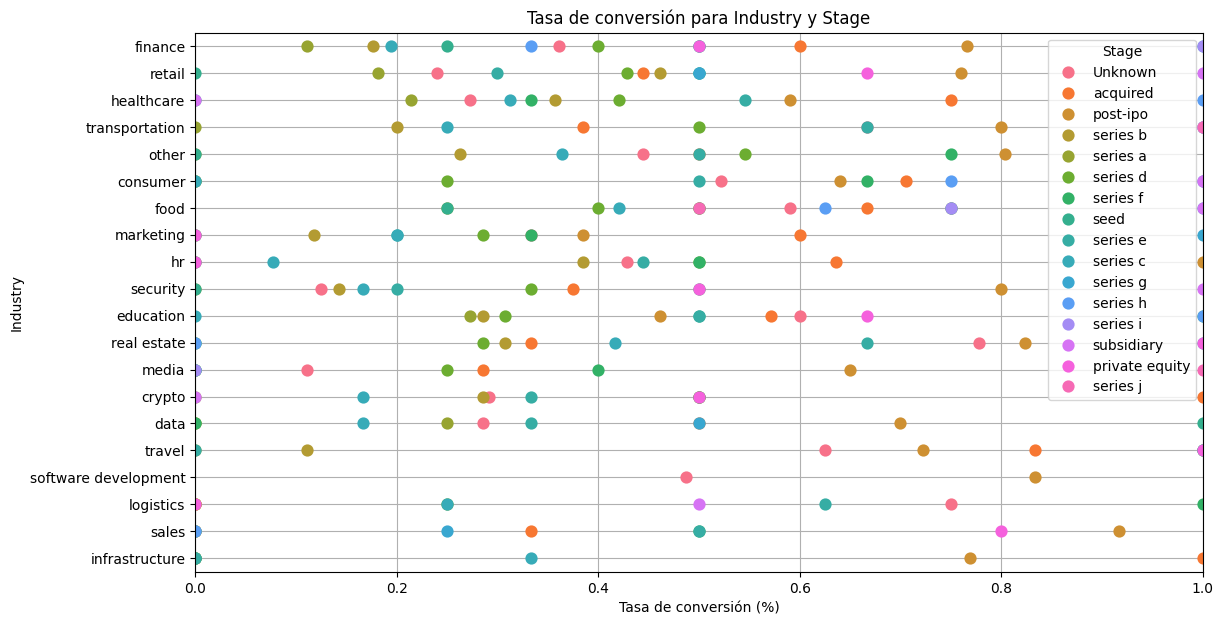

In [60]:
# 1. Par Industry-Stage
# Seleccionamos las 20 industrias principales para la visualización

# Definimos las industrias y etapas como están en tu CSV (en minúsculas)
top_20_ind = data['Industry'].value_counts().head(20).index
etapas_interes = ['post-ipo', 'series b', 'series c', 'series d']

# Filtramos los datos para que la grafica sea visible
data_biv = data[data['Industry'].isin(top_20_ind) & data['Stage'].isin(etapas_interes)]

# 3. Llamamos a la función con el dataframe filtrado
graficar_tc_bivariada(['Industry','Stage'], orden=top_20_ind)

# Tasas de conversión superiores al 70% con Stage == post-ipo y
# Industry = hr (100%), security (80%), transportation (80%), finance (76%), retail (76%) y food (75%)

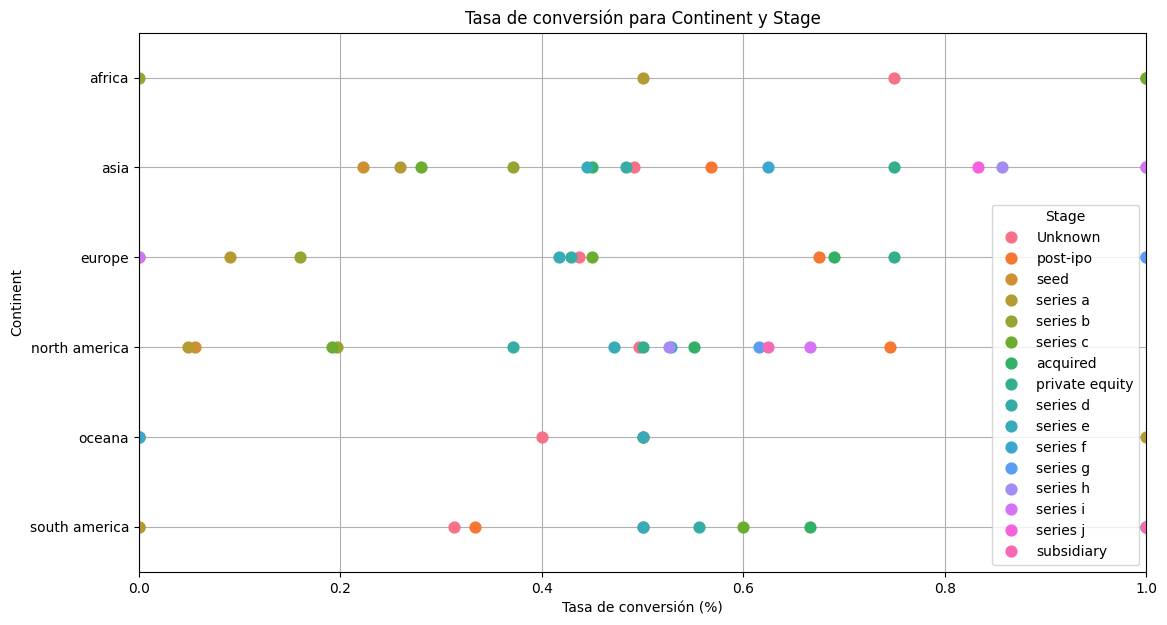

In [61]:
# 2. Par Continent-Stage
graficar_tc_bivariada(['Continent','Stage'])

# Tasas de conversión superiores al 80% con Stage == post-ipo y
# Continent = Asia (86.4%) y North America (72.1%)

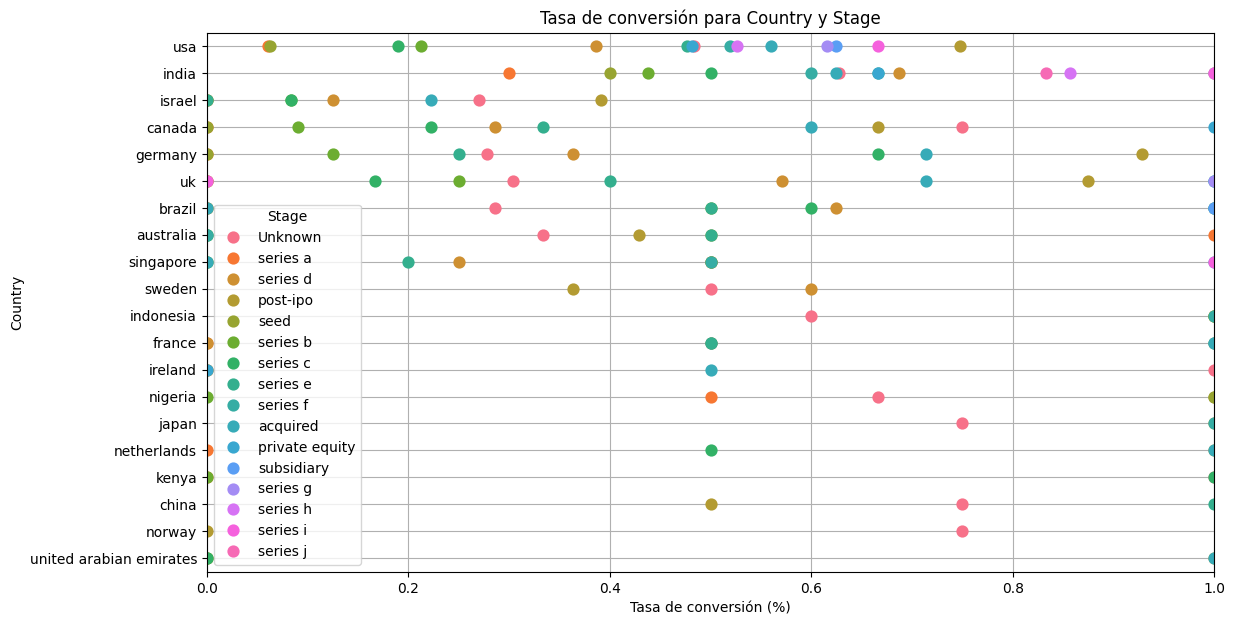

In [62]:
# 3. Par Country-Stage
top_20_paises = data['Country'].value_counts().head(20).index
graficar_tc_bivariada(['Country','Stage'], orden=top_20_paises)

# Tasas de conversión superiores al 85% con Stage == post-ipo y
# Country = india (93.3%), netherlands (100%) e indonesia (100%)

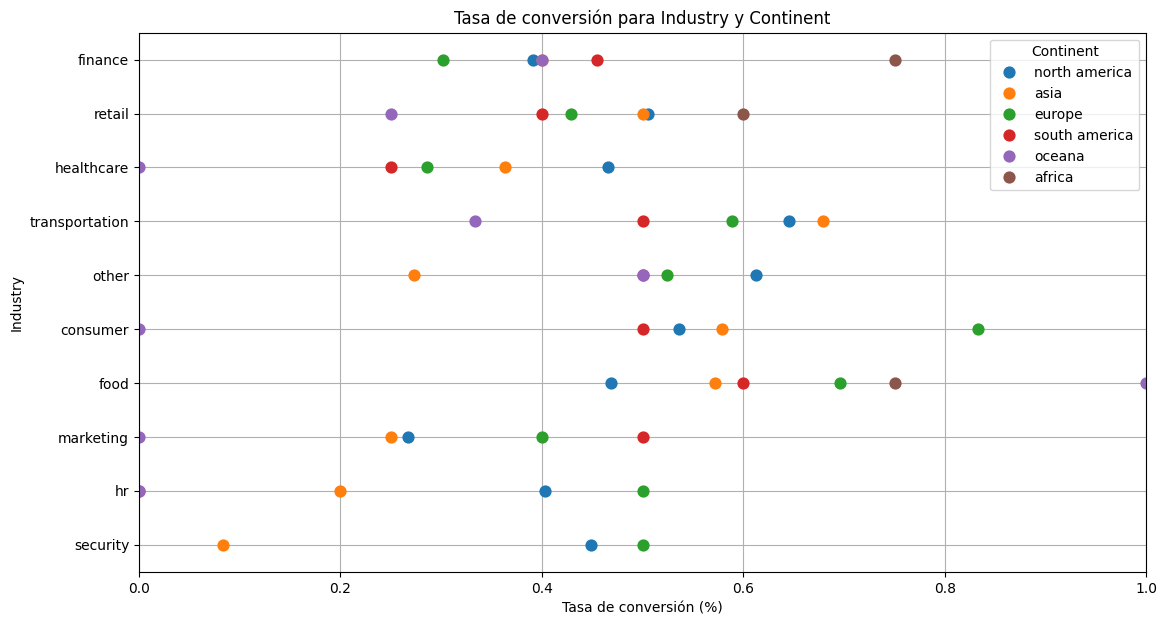

In [63]:
# 4. Par Industry-Continent
top_10_ind = data['Industry'].value_counts().head(10).index
graficar_tc_bivariada(['Industry','Continent'], orden=top_10_ind)

# Tasas de conversión superiores al 80% para Continent=Asia y
# - Industry = Education: 100%
# - Industry = Finance: 88%
# - Industry = Food: 83%

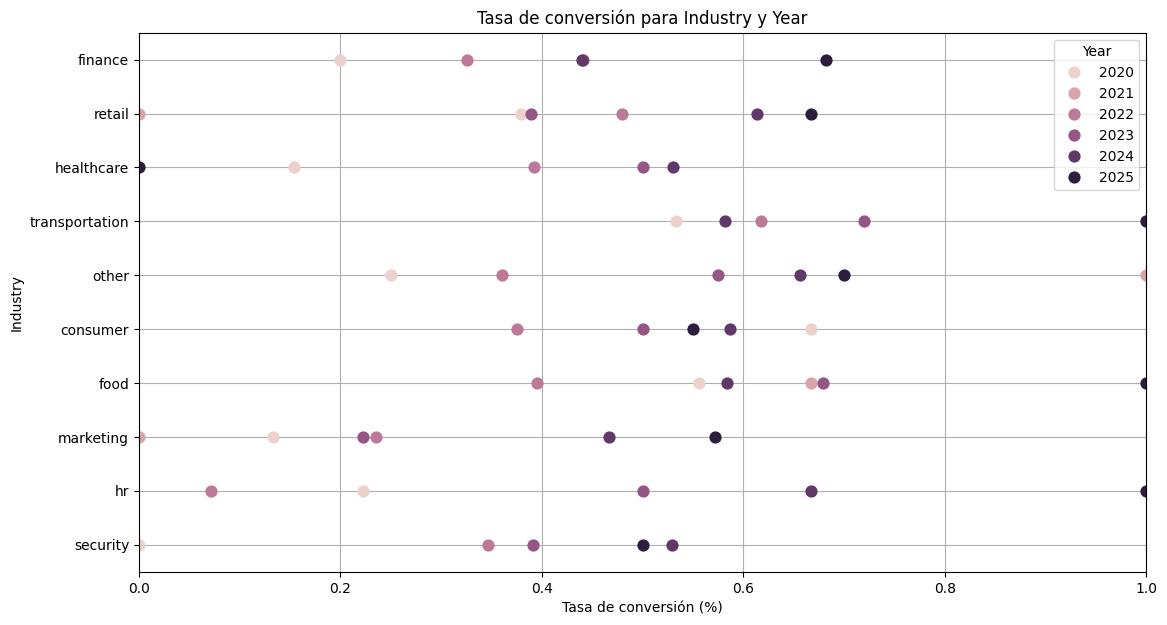

In [64]:
# 5. Par Industry-Year
top_10_ind = data['Industry'].value_counts().head(10).index
graficar_tc_bivariada(['Industry','Year'], orden=top_10_ind)

# Tasas de conversión superiores al 70% para Year=2023 y
# - Industry = Retail: 85%
# - Industry = Food: 78%
# - Industry = Transportation: 72%

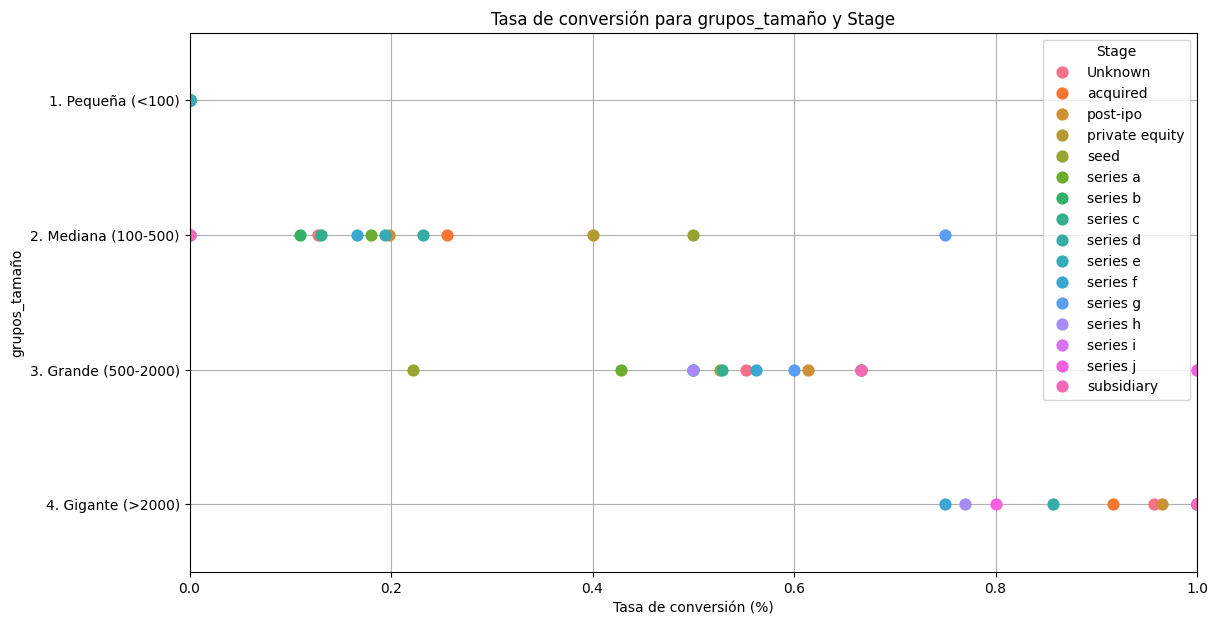

In [65]:
# 6. Par tamaño de la empresa antes de despidos (Company_Size_before_Layoffs) - Stage
# Creamos los grupos por tamaño de empresa (bins)
# Definimos rangos: Pequeña (<100), Mediana (100-500), Grande (500-2000), Gigante (>2000)
bins = [0, 100, 500, 2000, 1000000]
labels = ['1. Pequeña (<100)', '2. Mediana (100-500)', '3. Grande (500-2000)', '4. Gigante (>2000)']
data['grupos_tamaño'] = pd.cut(data['Company_Size_before_Layoffs'], bins=bins, labels=labels)

# 2. Par grupos_tamaño-Stage
graficar_tc_bivariada(['grupos_tamaño', 'Stage'])

# Tasas de conversión superiores al 75% para Stage=post-ipo y
# - Gigante (>2000): 92%
# - Grande (500-2000): 84%
# - Mediana (100-500): 76%

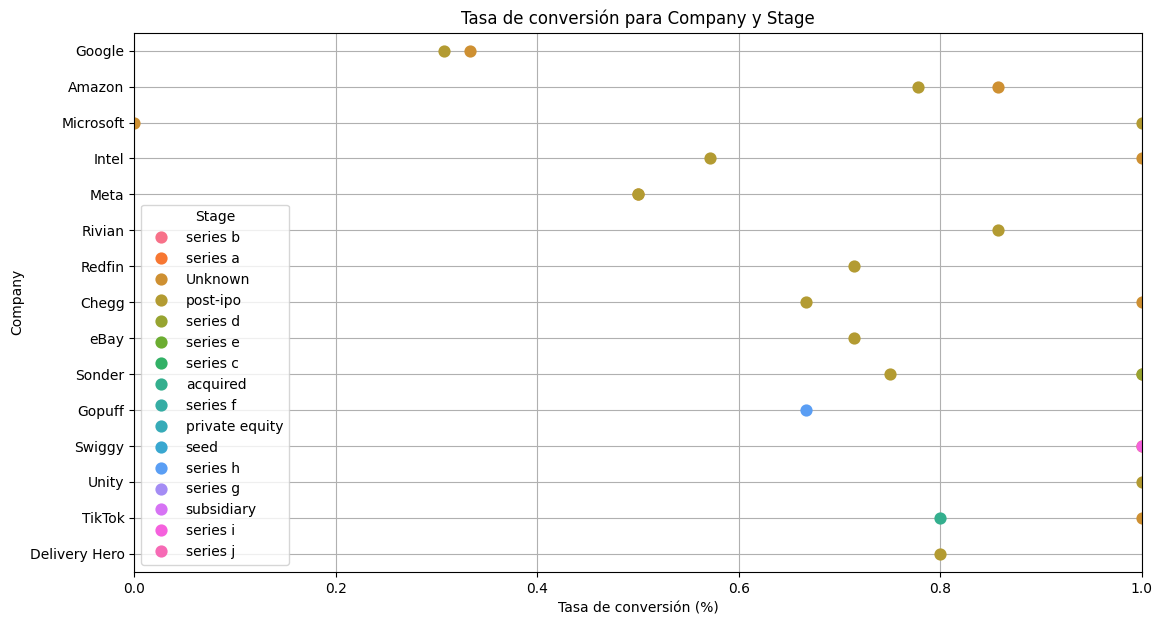

In [66]:
# 7. Par Company-Stage (Enfocado en las empresas con más impacto)
# Seleccionamos las empresas más frecuentes para que la gráfica sea legible
top_companies = data['Company'].value_counts().head(15).index
graficar_tc_bivariada(['Company', 'Stage'], orden=top_companies)

# Tasas de conversión de 100% para Stage=post-ipo y las siguientes Company:
# - Google: 100%
# - Microsoft: 100%
# - Meta: 100%
# - Amazon: 100%
# - Salesforce: 100%

# Conclusiones

- La variable `Stages`, `industry`, `Company_Size_before_Layoffs` (grupos_tamaño) y `Company` (específicamente las Big Tech) son las que tienen mayor impacto en la tasa de despidos masivos.

- Con este análisis, el perfil de la empresa con alto riesgo de realizar un despido masivo (evento > 100 personas) sería:
  - Debe ser una **empresa** con madurez financiera consolidada (stage == post-ipo).
  - Perfil **industrial** (top-3): hr (recursos humanos), sales (ventas) y finance (finanzas).
  - **Tamaño** de la empresa (`Company_Size_before_Layoffs`): Empresas clasificadas como Gigantes (>2000 empleados) o Grandes (500-2000 empleados).
  - Pertenecer al grupo de las **Big Tech (Google, Microsoft, Meta, Amazon) **garantiza prácticamente una tasa de conversión del 100% en eventos masivos.

Es posible que la combinación de más de dos variables (análisis multivariado) arroje más luces sobre estos perfiles de riesgo. Pero en este caso la interpretación de los resultados se dificulta a medida que analizamos de manera simultánea más y más variables (como cruzar al mismo tiempo la industria, el país y el año).

En este punto el paso a seguir sería usar algún modelo de Machine Learning que permita encontrar esos patrones que no resultan fáciles de ver con este análisis exploratorio.

In [67]:
# Renderizar a html
!pip install nbconvert
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [78]:
!jupyter nbconvert --to html --output "Limpieza__de_Datos_y_Analisis_Exploratorio_De_Datos_Tech_Layoffs_2020_2025" "/content/drive/MyDrive/Colab Notebooks/Limpieza_y_Analisis_Exploratorio_De_Datos_Tech_Layoffs_2020_2025.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Limpieza_y_Analisis_Exploratorio_De_Datos_Tech_Layoffs_2020_2025.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 21 image(s).
[NbConvertApp] Writing 4035074 bytes to /content/drive/MyDrive/Colab Notebooks/Limpieza__de_Datos_y_Analisis_Exploratorio_De_Datos_Tech_Layoffs_2020_2025.html
